# The 18 January 2026 eruption: from STIX QPPs to the severe SEP event

**Master analysis notebook** — M. Nedal (DIAS), with the OVSA/STIX/SEP collaboration.

On 18 January 2026, AR 4341 (β-γ, near central meridian) produced a long-duration X1.9 flare
(onset 17:27, peak 18:09, end 18:51 UT), a full-halo CME with projected speed above 2000 km/s,
and an S4 proton event — the largest >10 MeV enhancement since 2003, with no GLE.
STIX shows a train of quasi-periodic pulsations (QPPs) in the non-thermal hard X-ray bands.

**Science questions**

1. Nature of the flare energy release: QPP period(s) in STIX non-thermal X-rays, and whether
   the same rhythm appears in EOVSA microwaves, OVRO-LWA metric radio (type III groups), and
   the GOES SXR derivative.
2. Early CME acceleration and shock formation, and their relation to the high SEP flux and
   early arrival.
3. Shock geometry and magnetic connectivity as enablers of efficient particle acceleration
   and transport (Solar-MACH, PFSS, VDA/TSA release times vs the QPP interval).

**Workflow map** (sections):
§1 setup/config → §2 GOES overview → §3 STIX loading and cleaning → §4 QPP detrending and
pulse identification → §5 periodogram + wavelet + EMD with significance → §6 cross-instrument
rhythm (EOVSA, OVRO-LWA, GOES derivative) → §7 type IIIs vs HXR peaks, polarisation, LWA
imaging → §8 CME kinematics and type II shock diagnostics → §9 connectivity (Solar-MACH,
PFSS) → §10 SEP onsets, VDA/TSA → §11 synthesis timeline.

**Honesty caveats** (keep separate from results):
observation vs interpretation is flagged throughout; the flare-vs-shock split and any
QPP-to-escape link are hypotheses to test, not results. There is no European LOFAR coverage
(flare after local sunset over Europe); the low-frequency story rests on OVRO-LWA. Solar
Orbiter's vantage and connectivity are computed in §9 before any EPD claim is made.

## 1. Setup

Non-standard packages used here, install once on the analysis server:

```
pip install stixpy pycwt EMD-signal solo-epd-loader solarmach sunkit-magex cdflib xarray netCDF4 h5py
```

In [1]:
import numpy
import scipy
import astropy
import sunpy
import reproject
import sunpy.map

print('numpy:', numpy.__version__)
print('scipy:', scipy.__version__)
print('astropy:', astropy.__version__)
print('sunpy:', sunpy.__version__)

print('Everything OK')

numpy: 1.26.4
scipy: 1.15.2
astropy: 7.2.0
sunpy: 6.1.1
Everything OK


In [5]:
import warnings
warnings.filterwarnings('ignore')
import logging
import os
import glob
import json
import requests

import logging
import sunpy
import astropy

logging.getLogger('sunpy').setLevel(logging.WARNING)
logging.getLogger('astropy').setLevel(logging.WARNING)

import sunpy.map
import sunpy.timeseries as ts
from sunpy.net import Fido, attrs as a
from sunpy.coordinates import get_horizons_coord

import numpy as np
import pandas as pd
import astropy.units as u
from astropy.io import fits
from astropy.time import Time
from astropy.coordinates import SkyCoord
import astropy.constants as const

from scipy.signal import savgol_filter, find_peaks, correlate
from scipy.optimize import curve_fit, fsolve
from scipy.stats import chi2
from scipy.ndimage import gaussian_filter

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import colors
from tqdm import tqdm

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.size'] = 11

In [6]:
# Event facts, cross-checked against IRAP / ESA / NOAA reports (see the abstract file).
# Everything downstream reads times from this dict only.
event = {
    'date': '2026-01-18',
    'ar': 'AR 4341',
    'flare_class': 'X1.9',
    'flare_onset': '2026-01-18T17:27:00',
    'flare_peak': '2026-01-18T18:09:00',
    'flare_end': '2026-01-18T18:51:00',
    'type_iv_onset': '2026-01-18T18:13:00',
    'rstn_28ghz_start': '2026-01-18T17:39:00',
    'rstn_28ghz_end': '2026-01-18T19:44:00',
    'sep_peak': '2026-01-19T19:15:00',      # >10 MeV S4 peak at GOES
    'l1_shock': '2026-01-19T19:03:00',
    'type_ii_drift_speed_reported': 693,    # km/s, from RSTN metric drift rate (report value)
    'cme_projected_speed_reported': 2000,   # km/s, lower bound, LASCO plane-of-sky
}

t_flare = {k: pd.Timestamp(v) for k, v in event.items() if str(v).startswith('2026')}

# Analysis windows. The QPP episode is 17:40-18:15 UT: every pulsation step (cleaning,
# detrending, wavelet, EMD Monte Carlo, cross-correlation) runs on that window plus a
# small pad so detrending edge effects fall outside the science interval — never on
# full-day arrays. Daily files are still downloaded once, then sliced immediately.
qpp_window = ('2026-01-18T17:40:00', '2026-01-18T18:15:00')
qpp_pad = pd.Timedelta(minutes=3)
qpp_padded = (pd.Timestamp(qpp_window[0]) - qpp_pad, pd.Timestamp(qpp_window[1]) + qpp_pad)
radio_bkg_window = ('2026-01-18T16:30:00', '2026-01-18T17:20:00')  # quiet pre-flare baseline
stix_window = ('2026-01-18T17:00:00', '2026-01-18T19:00:00')       # display context only
overview_window = ('2026-01-18T16:00:00', '2026-01-18T21:00:00')
sep_window = ('2026-01-18T12:00:00', '2026-01-21T00:00:00')

In [7]:
# data_dir = '/home/mnedal/data'
data_dir = './'
event_dir = f'{data_dir}/2026-01-18'
fig_dir = f'{event_dir}/figures'
res_dir = f'{event_dir}/results'

paths = {
    'stix': f'{event_dir}/STIX',
    'goes': f'{event_dir}/XRS',
    'aia': f'{event_dir}/AIA',
    'eovsa': f'{event_dir}/EOVSA',        # spectrogram FITS from Bin/Sijie (OVSA team)
    'lwa_dyspec': f'{event_dir}/LWA',      # OVRO-LWA beam dynamic spectrum from Peijin
    'lwa_imaging': f'{event_dir}/LWA/imaging',  # ~10 s cadence imaging FITS (Google Drive link from Peijin)
    'lwa_stokes': f'{event_dir}/LWA/stokes',    # polarimetric products for Shilpi's analysis
    'lasco': f'{event_dir}/LASCO',
    'sep': f'{event_dir}/SEP',
    'gong': f'{event_dir}/GONG',
}

for p in [event_dir, fig_dir, res_dir, *paths.values()]:
    os.makedirs(p, exist_ok=True)

# Central store for measured quantities; exported as CSV in §11
results = {}

In [8]:
def savefig(fig, name):
    """Publication-quality export (PDF + PNG)."""
    fig.savefig(f'{fig_dir}/{name}.pdf', dpi=300, bbox_inches='tight')
    fig.savefig(f'{fig_dir}/{name}.png', dpi=300, bbox_inches='tight')
    print(f'saved {fig_dir}/{name}.pdf|png')


def to_seconds(t_index, t0=None):
    """Datetime index -> elapsed seconds (float array)."""
    t = pd.DatetimeIndex(t_index)
    if t0 is None:
        t0 = t[0]
    return (t - t0).total_seconds().values, t0


def standardise(x):
    return (x - np.nanmean(x)) / np.nanstd(x)


def resample_uniform(t_index, y, dt_s):
    """Interpolate a (possibly irregular) series onto a uniform grid of step dt_s seconds."""
    s = pd.Series(y, index=pd.DatetimeIndex(t_index)).dropna()
    grid = pd.date_range(s.index[0], s.index[-1], freq=f'{dt_s}s')
    out = np.interp(mdates.date2num(grid), mdates.date2num(s.index), s.values)
    return grid, out


def qpp_residual(t_index, flux, window_s=120, polyorder=3, dt_s=None):
    """
    Detrend a light curve for QPP work: uniform resampling, then subtract a
    Savitzky-Golay trend. Returns (grid, flux_i, trend, residual, norm_residual).
    Window choice matters (Broomhall et al. 2019) -- see the robustness scan in §5.
    """
    if dt_s is None:
        dt_s = np.median(np.diff(pd.DatetimeIndex(t_index).values).astype('timedelta64[ms]').astype(float)) / 1000
    grid, flux_i = resample_uniform(t_index, flux, dt_s)
    win = int(round(window_s / dt_s))
    if win % 2 == 0:
        win += 1
    trend = savgol_filter(flux_i, win, polyorder)
    resid = flux_i - trend
    return grid, flux_i, trend, resid, resid / np.nanstd(resid)

## 2. GOES/XRS overview and the SXR derivative

The soft X-ray derivative is the cheapest proxy for the energy-release rhythm
(Neupert effect) and one of the channels in which we test for the QPP period.

In [9]:
def load_goes_xrs(t0, t1, sat=18):
    result = Fido.search(a.Time(t0, t1), a.Instrument('XRS'),
                         a.goes.SatelliteNumber(sat), a.Resolution('flx1s'))
    files = Fido.fetch(result, path=f"{paths['goes']}/{{file}}")
    goes = ts.TimeSeries(files, concatenate=True)
    return goes.truncate(t0, t1)


goes = load_goes_xrs(*overview_window)
gdf = goes.to_dataframe()
gdf = gdf[gdf['xrsb_quality'] == 0] if 'xrsb_quality' in gdf else gdf

# 1-min smoothing before differentiating, otherwise the derivative is noise-dominated
xrsb = gdf['xrsb'].resample('4s').mean().interpolate()
sxr_deriv = pd.Series(np.gradient(xrsb.values, 4), index=xrsb.index)
sxr_deriv_smooth = sxr_deriv.rolling(15, center=True).mean()

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

saved .//2026-01-18/figures/goes_overview.pdf|png


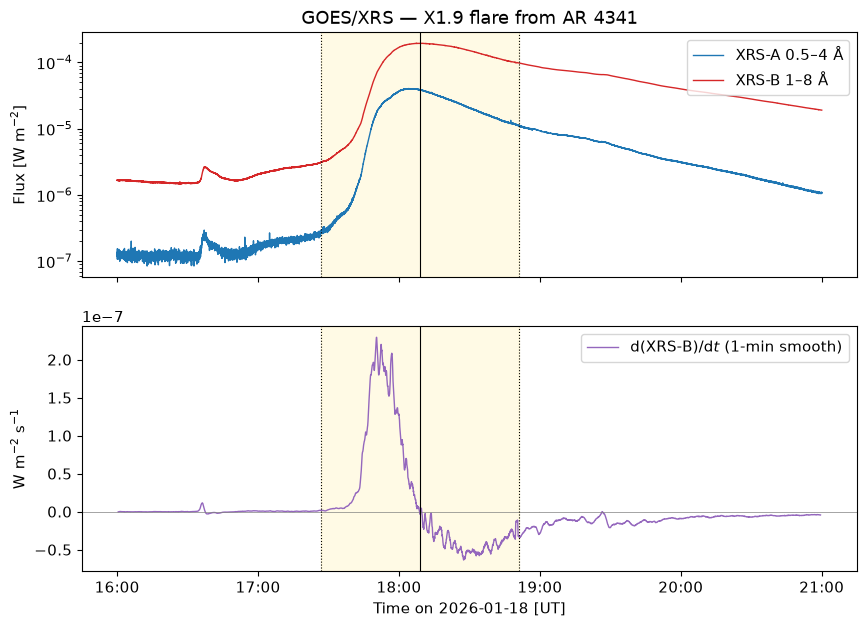

In [10]:
fig, axs = plt.subplots(2, 1, figsize=[10, 7], sharex=True)

axs[0].plot(gdf.index, gdf['xrsa'], lw=1, color='tab:blue', label='XRS-A 0.5–4 Å')
axs[0].plot(gdf.index, gdf['xrsb'], lw=1, color='tab:red', label='XRS-B 1–8 Å')
axs[0].set_yscale('log')
axs[0].set_ylabel('Flux [W m$^{-2}$]')
axs[0].legend(loc='upper right')

axs[1].plot(sxr_deriv_smooth.index, sxr_deriv_smooth, lw=1, color='tab:purple',
            label=r'd(XRS-B)/d$t$ (1-min smooth)')
axs[1].axhline(0, color='grey', lw=0.5)
axs[1].set_ylabel(r'W m$^{-2}$ s$^{-1}$')
axs[1].legend(loc='upper right')

for ax in axs:
    for key, ls in zip(['flare_onset', 'flare_peak', 'flare_end'], [':', '-', ':']):
        ax.axvline(t_flare[key], color='k', ls=ls, lw=0.8)
    ax.axvspan(t_flare['flare_onset'], t_flare['flare_end'], color='gold', alpha=0.1)

axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1].set_xlabel(f"Time on {event['date']} [UT]")
axs[0].set_title(f"GOES/XRS — {event['flare_class']} flare from {event['ar']}")
fig.align_ylabels(axs)
savefig(fig, 'goes_overview')
plt.show()

## 3. STIX: loading and cleaning the hard X-ray light curves

Two instrumental effects will contaminate any wavelet/Fourier/EMD analysis if ignored
(Shane's warning): (i) **attenuator movements** — the rate-control regime (RCR) inserts or
removes the Al attenuator during large flares, producing step artefacts; (ii) **variable
integration time** — QL light curves are not guaranteed to have a constant `timedel`.
The cleaning strategy: convert counts to rates with the *actual* per-bin `timedel`, flag RCR
changes, mask a guard interval around each change, then interpolate onto a uniform grid.
Periods comparable to, or shorter than, twice the longest integration time are not trustworthy.

Light-travel-time note: STIX times are corrected to Earth-received UT (or not) depending on
product/version — record which convention is used before comparing with GOES/EOVSA
(`date-obs` keywords; stixpy exposes the Earth arrival correction). Flag this in the timing table.

In [11]:
from stixpy.net.client import STIXClient  # noqa: F401  (registers the STIX Fido client)
from stixpy.product import Product

stix_query = Fido.search(a.Time(*overview_window), a.Instrument('STIX'),
                         a.stix.DataType('ql'), a.stix.DataProduct.ql_lightcurve)
stix_files = Fido.fetch(stix_query, path=f"{paths['stix']}/{{file}}")
print(stix_files)

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

['2026-01-18/STIX/solo_L1_stix-ql-lightcurve_20260118_V02.fits']


In [12]:
ql = Product(sorted(stix_files)[0])
print(ql)
print(ql.data.colnames)

# QL energy bands: 4-10, 10-15, 15-25, 25-50, 50-84 keV
stix_bands = ['4-10 keV', '10-15 keV', '15-25 keV', '25-50 keV', '50-84 keV']

stix_time = pd.DatetimeIndex(ql.data['time'].datetime)
timedel = np.atleast_1d(ql.data['timedel'].to_value(u.s))
counts = np.asarray(ql.data['counts'])
rate = counts / timedel[:, None]

rcr = np.asarray(ql.data['rcr']) if 'rcr' in ql.data.colnames else np.zeros(len(stix_time))

# QL files are daily — slice to the flare context window straight away so nothing
# downstream ever touches 24 h of data
keep = (stix_time >= pd.Timestamp(stix_window[0])) & (stix_time <= pd.Timestamp(stix_window[1]))
stix_time = stix_time[keep]
timedel = timedel[keep]
rate = rate[keep]
rcr = rcr[keep]

print(f'{keep.sum()} samples kept in {stix_window[0][11:16]}-{stix_window[1][11:16]} UT')
print(f'integration times present: {np.unique(timedel)} s')
print(f'RCR states present: {np.unique(rcr)}')

QLLightCurve
    Start: 2026-01-17 23:59:58
    End:   2026-01-18 23:59:58
    Center:2026-01-18 11:59:58
    Duration:0.9999976851851851 days or
           23.99994444444444 hours or
           1439.9966666666664 minutes or
           86399.79999999999 seconds

['control_index', 'time', 'timedel', 'triggers', 'triggers_comp_err', 'rcr', 'counts', 'counts_comp_err']
1800 samples kept in 17:00-19:00 UT
integration times present: [4.] s
RCR states present: [0 1]


In [13]:
def clean_stix_band(t_index, rate_band, rcr, timedel, dt_s=4, guard_s=20):
    """
    Mask a guard interval around every RCR (attenuator) change, then interpolate
    the rate onto a uniform dt_s grid. Returns (grid, rate_i, mask_uniform).
    The mask is carried forward so masked stretches can be shaded in plots and
    excluded from significance statistics.
    """
    t = pd.DatetimeIndex(t_index)
    changes = np.where(np.diff(rcr) != 0)[0]
    bad = np.zeros(len(t), dtype=bool)
    for i in changes:
        t_ch = t[i]
        bad |= (t >= t_ch - pd.Timedelta(seconds=guard_s)) & (t <= t_ch + pd.Timedelta(seconds=guard_s))
    # also distrust bins with unusually long integration (rate ok, but frequency response differs)
    bad |= timedel > 2 * np.median(timedel)

    s = pd.Series(np.where(bad, np.nan, rate_band), index=t)
    grid = pd.date_range(t[0], t[-1], freq=f'{dt_s}s')
    rate_i = pd.Series(np.interp(mdates.date2num(grid), mdates.date2num(t[~bad]), s.dropna().values), index=grid)
    mask_u = pd.Series(bad.astype(float), index=t).reindex(grid, method='nearest').astype(bool)
    return grid, rate_i.values, mask_u.values


stix = {}
for j, band in enumerate(stix_bands):
    grid, r_i, m_u = clean_stix_band(stix_time, rate[:, j], rcr, timedel)
    stix[band] = {'t': grid, 'rate': r_i, 'mask': m_u}

saved .//2026-01-18/figures/stix_lightcurves_clean.pdf|png


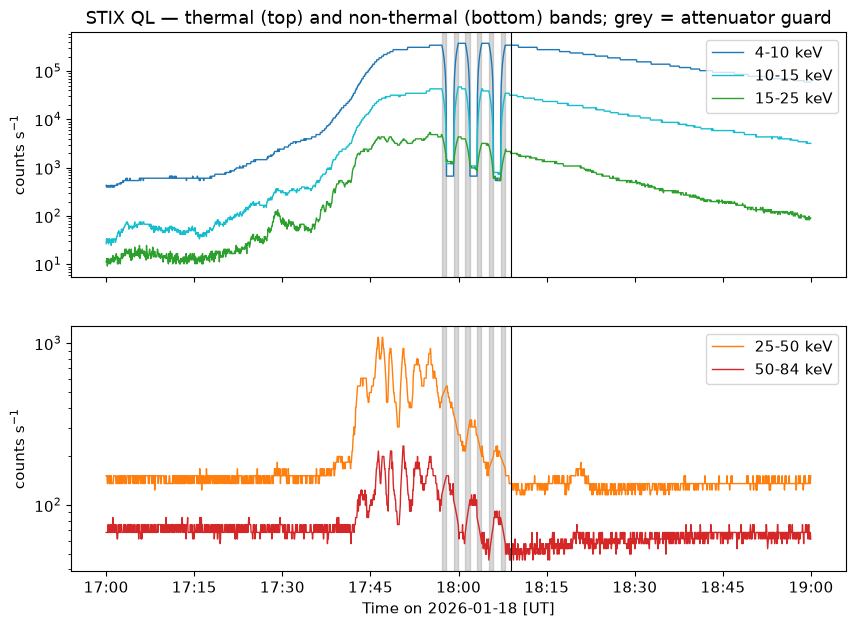

In [14]:
fig, axs = plt.subplots(2, 1, figsize=[10, 7], sharex=True)

for band, color in zip(stix_bands[:3], ['tab:blue', 'tab:cyan', 'tab:green']):
    axs[0].plot(stix[band]['t'], stix[band]['rate'], lw=1, color=color, label=band)
for band, color in zip(stix_bands[3:], ['tab:orange', 'tab:red']):
    axs[1].plot(stix[band]['t'], stix[band]['rate'], lw=1, color=color, label=band)

# shade attenuator-guard intervals so no one over-reads features there
m = stix[stix_bands[0]]['mask']
t_g = stix[stix_bands[0]]['t']
for seg_start, seg_end in zip(t_g[np.flatnonzero(np.diff(m.astype(int)) == 1)],
                              t_g[np.flatnonzero(np.diff(m.astype(int)) == -1)]):
    for ax in axs:
        ax.axvspan(seg_start, seg_end, color='grey', alpha=0.3)

for ax in axs:
    ax.set_yscale('log')
    ax.set_ylabel('counts s$^{-1}$')
    ax.legend(loc='upper right')
    ax.axvline(t_flare['flare_peak'], color='k', lw=0.8)

axs[0].set_title('STIX QL — thermal (top) and non-thermal (bottom) bands; grey = attenuator guard')
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1].set_xlabel(f"Time on {event['date']} [UT]")
savefig(fig, 'stix_lightcurves_clean')
plt.show()

## 4. QPP extraction: detrending and pulse identification

Working series: the two non-thermal bands (25–50, 50–84 keV), restricted to the impulsive
phase. Detrending uses the Savitzky-Golay residual (as in `qpp_residuals.ipynb`); the
window is a free parameter and §5 scans it, because apparent periods can be created or
destroyed by the trend choice (Broomhall et al. 2019).

In [15]:
band_nt = '25-50 keV'
# detrend over the padded window, then crop to the science window so the
# Savitzky-Golay edge effects never enter the analysis
sel = (stix[band_nt]['t'] >= qpp_padded[0]) & (stix[band_nt]['t'] <= qpp_padded[1])
t_nt = stix[band_nt]['t'][sel]
r_nt = stix[band_nt]['rate'][sel]
mask_nt = stix[band_nt]['mask'][sel]

grid_p, flux_p, trend_p, resid_p, _ = qpp_residual(t_nt, r_nt, window_s=120, polyorder=3, dt_s=4)
core = (grid_p >= pd.Timestamp(qpp_window[0])) & (grid_p <= pd.Timestamp(qpp_window[1]))
grid_nt = grid_p[core]
flux_i = flux_p[core]
trend = trend_p[core]
resid = resid_p[core]
resid_n = resid / np.nanstd(resid)

In [16]:
# Pulse identification on the normalised residual
peaks, props = find_peaks(resid_n, prominence=1, distance=int(10 / 4))
pulse_times = grid_nt[peaks]
waiting_times = np.diff(pulse_times).astype('timedelta64[s]').astype(float)

print(f'{len(peaks)} pulses; median waiting time {np.median(waiting_times):.1f} s')
results['n_pulses_25_50'] = len(peaks)
results['median_waiting_time_s'] = float(np.median(waiting_times))

19 pulses; median waiting time 56.0 s


In [17]:
def gaussian(x, amp, mu, sig):
    return amp * np.exp(-(x - mu)**2 / (2 * sig**2))


tsec, t0_nt = to_seconds(grid_nt)
pulse_fits = []
for pk in tqdm(peaks, desc='Fitting pulses'):
    half = int(round(0.6 * np.median(waiting_times) / 4))
    lo = max(pk - half, 0)
    hi = min(pk + half, len(tsec) - 1)
    try:
        popt, pcov = curve_fit(gaussian, tsec[lo:hi], resid[lo:hi],
                               p0=[resid[pk], tsec[pk], 20])
        perr = np.sqrt(np.diag(pcov))
        pulse_fits.append({'t_peak': t0_nt + pd.Timedelta(seconds=popt[1]),
                           'amp': popt[0], 'fwhm_s': 2.355 * abs(popt[2]),
                           'amp_err': perr[0], 'fwhm_err_s': 2.355 * perr[2]})
    except RuntimeError:
        pulse_fits.append({'t_peak': grid_nt[pk], 'amp': resid[pk], 'fwhm_s': np.nan,
                           'amp_err': np.nan, 'fwhm_err_s': np.nan})

pulse_df = pd.DataFrame(pulse_fits)
pulse_df.to_csv(f'{res_dir}/stix_pulse_fits_{band_nt.replace(" ", "")}.csv', index=False)
pulse_df

Fitting pulses: 100%|██████████| 19/19 [00:00<00:00, 473.65it/s]


,t_peak,amp,fwhm_s,amp_err,fwhm_err_s
0,2026-01-18 17:42:49.422375818,52.477152,12.533498,2.147638e+01,5.923558
1,2026-01-18 17:43:40.023982945,-69.253099,3.357911,1.359171e+02,9.259453
2,2026-01-18 17:44:11.303752546,60.435803,13.947469,2.804503e+01,7.472829
3,2026-01-18 17:45:13.672774351,47.764371,9.045712,3.836918e+01,8.421316
4,2026-01-18 17:46:15.731663405,189.783700,13.911906,8.302358e+01,7.027044
5,2026-01-18 17:47:09.942160164,187.408373,19.769385,7.197415e+01,8.774938
6,2026-01-18 17:48:22.943994300,239.191266,18.694989,8.073597e+01,7.286734
7,2026-01-18 17:49:22.134391126,73.279654,11.173033,5.498417e+01,9.685483
8,2026-01-18 17:50:33.663234047,167.808204,17.337214,2.519351e+01,3.005443
9,2026-01-18 17:51:44.413000000,16.590555,NaN,NaN,NaN


saved .//2026-01-18/figures/stix_qpp_pulses_25-50keV.pdf|png


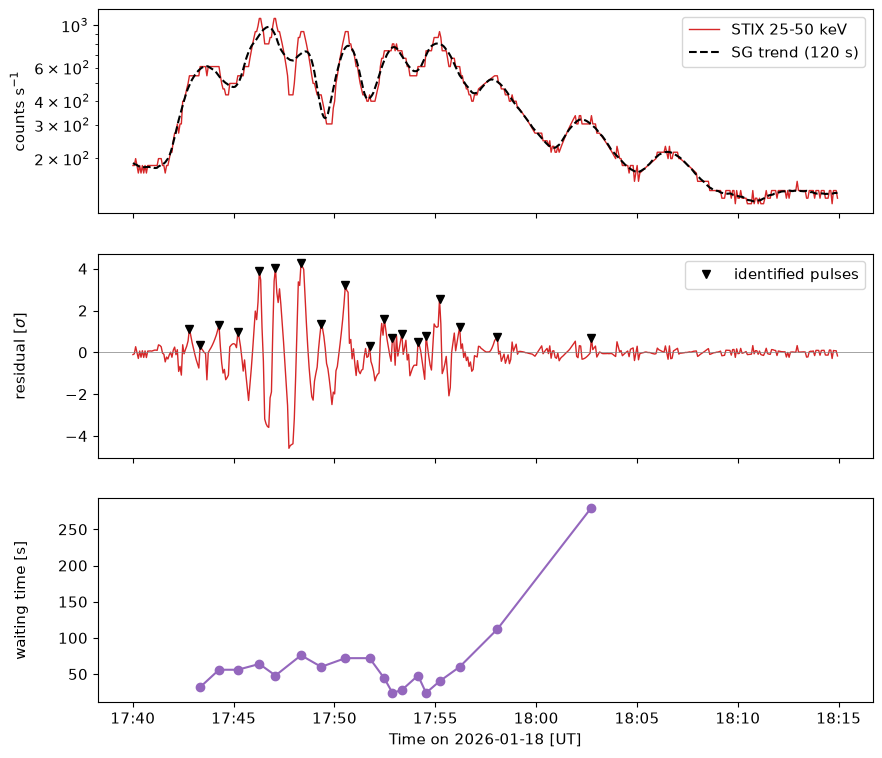

In [18]:
fig, axs = plt.subplots(3, 1, figsize=[10, 9], sharex=True)

axs[0].plot(grid_nt, flux_i, lw=1, color='tab:red', label=f'STIX {band_nt}')
axs[0].plot(grid_nt, trend, lw=1.5, color='k', ls='--', label='SG trend (120 s)')
axs[0].set_yscale('log')
axs[0].set_ylabel('counts s$^{-1}$')

axs[1].plot(grid_nt, resid_n, lw=1, color='tab:red')
axs[1].plot(grid_nt[peaks], resid_n[peaks], 'kv', ms=6, label='identified pulses')
axs[1].axhline(0, color='grey', lw=0.5)
axs[1].set_ylabel(r'residual [$\sigma$]')

axs[2].plot(pulse_times[1:], waiting_times, 'o-', color='tab:purple')
axs[2].set_ylabel('waiting time [s]')
axs[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[2].set_xlabel(f"Time on {event['date']} [UT]")

for ax in axs[:2]:
    ax.legend(loc='upper right')
fig.align_ylabels(axs)
savefig(fig, f'stix_qpp_pulses_{band_nt.replace(" ", "")}')
plt.show()

### 4.1 Per-pulse spectral evolution (hardening/softening)

STIX measures X-rays, not electrons: the pulse-by-pulse quantity tracked here is the
**hard X-ray count-spectrum slope** between the non-thermal QL bands; the electron spectrum
is a derived quantity and the full thermal + thick-target forward fit belongs in
OSPEX/STIX-GSW (or stixpy spectroscopy) using the L1 `sci-xspec` product:
`Fido.search(..., a.stix.DataProduct.sci_xray_spec)`.
The band-ratio proxy below is cadence-friendly and fine for *relative* pulse-to-pulse
hardness, not for absolute spectral indices.

saved .//2026-01-18/figures/stix_perpulse_hardness_proxy.pdf|png


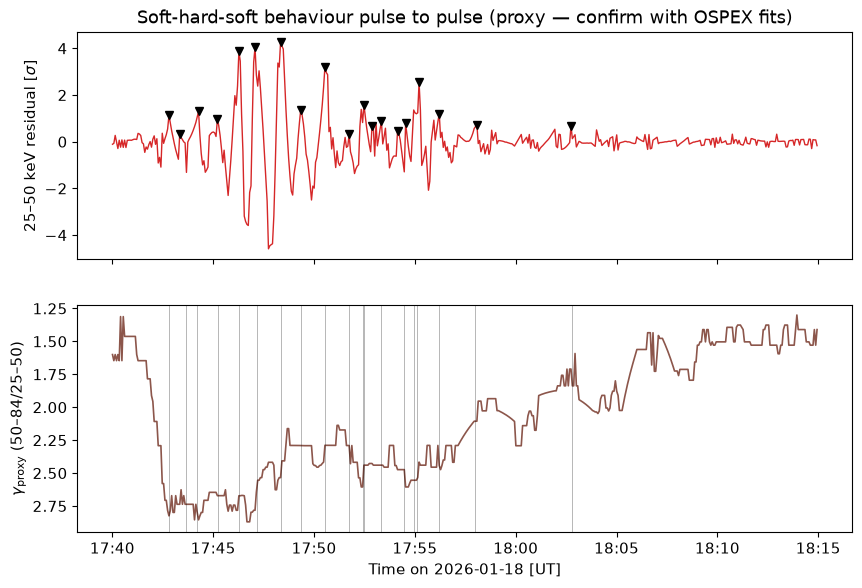

In [19]:
s25 = pd.Series(stix['25-50 keV']['rate'], index=stix['25-50 keV']['t'])
s50 = pd.Series(stix['50-84 keV']['rate'], index=stix['50-84 keV']['t'])

# effective count-spectrum slope between geometric-mean energies 35.4 and 64.8 keV
e1 = np.sqrt(25 * 50)
e2 = np.sqrt(50 * 84)
with np.errstate(divide='ignore', invalid='ignore'):
    gamma_proxy = -np.log(s50 / s25) / np.log(e2 / e1)

# align on the cropped QPP grid
gamma_s = gamma_proxy.rolling(5, center=True).median().reindex(grid_nt, method='nearest')

fig, axs = plt.subplots(2, 1, figsize=[10, 6.5], sharex=True)
axs[0].plot(grid_nt, resid_n, lw=1, color='tab:red')
axs[0].plot(grid_nt[peaks], resid_n[peaks], 'kv', ms=6)
axs[0].set_ylabel(r'25–50 keV residual [$\sigma$]')

axs[1].plot(gamma_s.index, gamma_s, lw=1.2, color='tab:brown')
for tp in pulse_df['t_peak']:
    axs[1].axvline(tp, color='k', lw=0.5, alpha=0.4)
axs[1].invert_yaxis()  # up = harder
axs[1].set_ylabel(r'$\gamma_{\rm proxy}$ (50–84/25–50)')
axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axs[1].set_xlabel(f"Time on {event['date']} [UT]")
axs[0].set_title('Soft-hard-soft behaviour pulse to pulse (proxy — confirm with OSPEX fits)')
savefig(fig, 'stix_perpulse_hardness_proxy')
plt.show()

## 5. Period analysis with significance testing

Three independent methods on the same residual, each with a noise model, following the
recommendations of Broomhall et al. (2019, ApJS 244, 44) — Laura's reference:

1. **Fourier periodogram** against a fitted broken/power-law red-noise background with
   $\chi^2_2$ confidence levels and a trial-number (global) correction (Vaughan 2005;
   Pugh et al. 2017). Applied to the *undetrended* series as well, since detrending
   distorts the low-frequency part of the spectrum.
2. **Morlet wavelet** with an AR(1) red-noise significance test and the cone of
   influence (Torrence & Compo 1998), via `pycwt`.
3. **EMD** (as in the preliminary analysis) with a Monte-Carlo significance envelope:
   coloured-noise realisations matched to the fitted spectral slope are decomposed and
   the IMF energy-period distribution of the noise bounds the observed IMFs
   (in the spirit of Kolotkov et al. 2016).

A detection is only claimed when the period is consistent across methods, stable against
the detrend window, and away from masked attenuator intervals.

In [20]:
def periodogram(x, dt):
    n = len(x)
    freqs = np.fft.rfftfreq(n, dt)[1:]
    power = (np.abs(np.fft.rfft(x - np.mean(x)))**2)[1:] * 2 * dt / n
    return freqs, power


def powerlaw_model(f, logA, alpha, logC):
    return 10**logA * f**(-alpha) + 10**logC


def fit_rednoise(freqs, power):
    """Fit P(f) = A f^-alpha + C in log space (Vaughan 2005 least-squares variant)."""
    def logmodel(logf, logA, alpha, logC):
        return np.log10(powerlaw_model(10**logf, logA, alpha, logC))
    p0 = [np.log10(power[0]), 1.5, np.log10(np.median(power[-len(power) // 5:]))]
    popt, pcov = curve_fit(logmodel, np.log10(freqs), np.log10(power), p0=p0, maxfev=20000)
    return popt, np.sqrt(np.diag(pcov))


def confidence_levels(freqs, popt, n_freq, levels=(0.95, 0.99)):
    """
    Local and global (trial-corrected) confidence levels.
    Periodogram/model ~ chi2_2/2, so P_conf = model * chi2.ppf(p, 2)/2.
    Global: p_global = (1 - eps)^(1/n_freq) for a family-wise rate eps.
    """
    model = powerlaw_model(freqs, *popt)
    out = {}
    for lv in levels:
        out[f'local_{lv}'] = model * chi2.ppf(lv, 2) / 2
        lv_g = (1 - (1 - lv))**(1 / n_freq)
        out[f'global_{lv}'] = model * chi2.ppf(lv_g, 2) / 2
    return model, out


dt_s = 4
freqs, power = periodogram(resid, dt_s)
freqs_raw, power_raw = periodogram(flux_i, dt_s)

popt, perr = fit_rednoise(freqs_raw, power_raw)
model, confs = confidence_levels(freqs_raw, popt, len(freqs_raw))
print(f'red-noise slope alpha = {popt[1]:.2f} +/- {perr[1]:.2f}')
results['rednoise_alpha'] = round(float(popt[1]), 2)

red-noise slope alpha = 2.20 +/- inf


saved .//2026-01-18/figures/stix_periodogram_rednoise.pdf|png


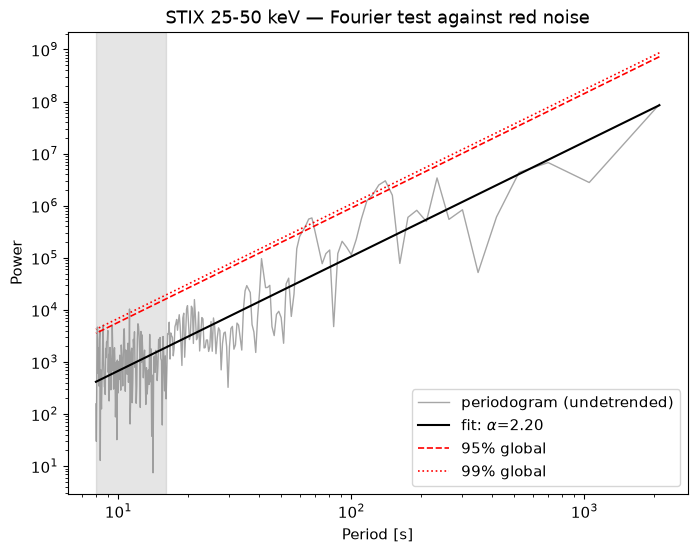

periods above 95% global: [140.  131.2 123.5  67.7  65.6  63.6  61.8  11.2   9.4   8.6   8.3   8.1] s


In [21]:
fig, ax = plt.subplots(figsize=[8, 6])
ax.loglog(1 / freqs_raw, power_raw, lw=1, color='grey', alpha=0.7, label='periodogram (undetrended)')
ax.loglog(1 / freqs_raw, model, 'k-', lw=1.5, label=fr'fit: $\alpha$={popt[1]:.2f}')
ax.loglog(1 / freqs_raw, confs['global_0.95'], 'r--', lw=1.2, label='95% global')
ax.loglog(1 / freqs_raw, confs['global_0.99'], 'r:', lw=1.2, label='99% global')
ax.axvspan(2 * dt_s, 4 * dt_s, color='grey', alpha=0.2)  # near-Nyquist, do not interpret
ax.set_xlabel('Period [s]')
ax.set_ylabel('Power')
ax.set_title(f'STIX {band_nt} — Fourier test against red noise')
ax.legend()
savefig(fig, 'stix_periodogram_rednoise')
plt.show()

above = power_raw > confs['global_0.95']
if above.any():
    print('periods above 95% global:', np.round(1 / freqs_raw[above], 1), 's')
    results['fourier_periods_s'] = list(np.round(1 / freqs_raw[above], 1))

### 5.1 Wavelet (Morlet), red-noise significance, COI

In [22]:
import pycwt

sig = standardise(resid)
mother = pycwt.Morlet(6)
alpha_ar1, _, _ = pycwt.ar1(sig)

wave, scales, wfreqs, coi, fft_w, fftfreqs = pycwt.cwt(sig, dt_s, dj=1 / 12, s0=2 * dt_s,
                                                       J=int(7 / (1 / 12)), wavelet=mother)
wpower = np.abs(wave)**2
periods = 1 / wfreqs

signif, fft_theor = pycwt.significance(1, dt_s, scales, 0, alpha_ar1,
                                       significance_level=0.95, wavelet=mother)
sig95 = wpower / (signif[:, None])

glbl_power = wpower.mean(axis=1)
dof = sig.size - scales
glbl_signif, _ = pycwt.significance(1, dt_s, scales, 1, alpha_ar1,
                                    significance_level=0.95, dof=dof, wavelet=mother)

saved .//2026-01-18/figures/stix_wavelet.pdf|png


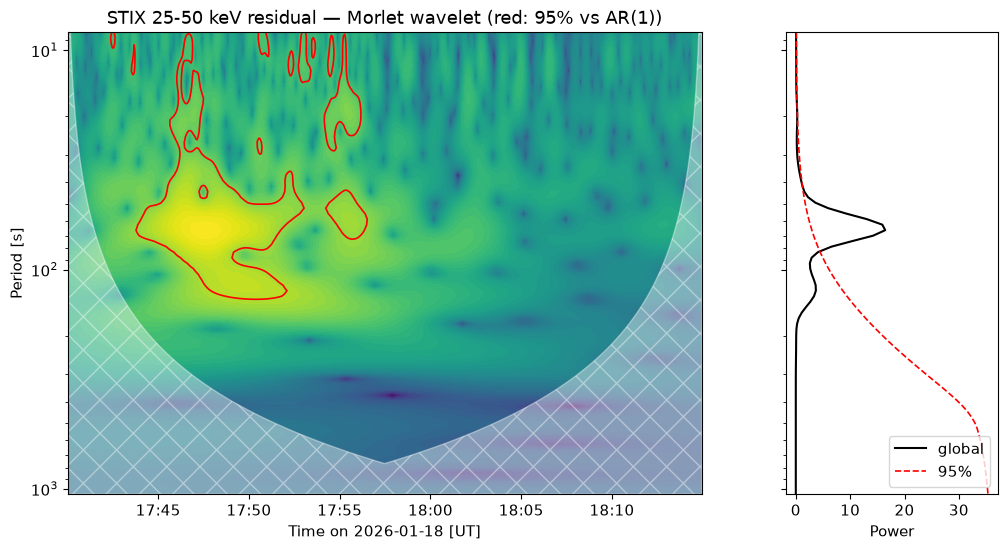

dominant significant wavelet period: 66.1 s


In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=[12, 6], width_ratios=[3, 1], sharey=True)

tnum = mdates.date2num(grid_nt)
cf = ax1.contourf(tnum, periods, np.log2(wpower), levels=64, cmap='viridis')
ax1.contour(tnum, periods, sig95, [1], colors='r', linewidths=1.2)
ax1.fill_between(tnum, coi, periods.max(), color='w', alpha=0.4, hatch='x')
ax1.set_yscale('log')
ax1.set_ylim(periods.max(), periods.min())
ax1.set_ylabel('Period [s]')
ax1.xaxis_date()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.set_xlabel(f"Time on {event['date']} [UT]")
ax1.set_title(f'STIX {band_nt} residual — Morlet wavelet (red: 95% vs AR(1))')

ax2.plot(glbl_power, periods, 'k-', lw=1.5, label='global')
ax2.plot(glbl_signif, periods, 'r--', lw=1.2, label='95%')
ax2.set_xlabel('Power')
ax2.legend(loc='lower right')
savefig(fig, 'stix_wavelet')
plt.show()

glbl_above = glbl_power > glbl_signif
if glbl_above.any():
    p_dom = periods[glbl_above][np.argmax(glbl_power[glbl_above])]
    print(f'dominant significant wavelet period: {p_dom:.1f} s')
    results['wavelet_period_s'] = round(float(p_dom), 1)

### 5.2 EMD with a Monte-Carlo coloured-noise envelope

Each IMF gets a characteristic period from its zero-crossing count. Significance: decompose
`n_mc` synthetic coloured-noise series (spectral slope $\alpha$ from §5, same variance and
length), and take the 95th percentile of noise-IMF energy as a function of period.

In [24]:
from PyEMD import EMD


def imf_period(imf, dt):
    zc = np.sum(np.abs(np.diff(np.sign(imf))) > 0)
    return 2 * len(imf) * dt / zc if zc > 0 else np.inf


def coloured_noise(n, alpha, rng):
    """FFT-method noise with P(f) ~ f^-alpha, unit variance."""
    f = np.fft.rfftfreq(n, 1)
    amp = np.zeros_like(f)
    amp[1:] = f[1:]**(-alpha / 2)
    phase = rng.uniform(0, 2 * np.pi, len(f))
    spec = amp * np.exp(1j * phase)
    x = np.fft.irfft(spec, n)
    return (x - x.mean()) / x.std()


emd = EMD()
imfs = emd(sig)
imf_periods = np.array([imf_period(imf, dt_s) for imf in imfs])
imf_energies = np.array([np.sum(imf**2) for imf in imfs])
print('IMF periods [s]:', np.round(imf_periods, 1))

n_mc = 200
rng = np.random.default_rng(7)
mc_p = []
mc_e = []
for _ in tqdm(range(n_mc), desc='EMD Monte Carlo'):
    xn = coloured_noise(len(sig), popt[1], rng)
    imfs_n = emd(xn)
    for imf in imfs_n:
        mc_p.append(imf_period(imf, dt_s))
        mc_e.append(np.sum(imf**2))

mc_p = np.array(mc_p)
mc_e = np.array(mc_e)

pbins = np.logspace(np.log10(2 * dt_s), np.log10(len(sig) * dt_s / 2), 12)
env95 = np.array([np.percentile(mc_e[(mc_p >= lo) & (mc_p < hi)], 95)
                  if ((mc_p >= lo) & (mc_p < hi)).sum() > 10 else np.nan
                  for lo, hi in zip(pbins[:-1], pbins[1:])])
pcent = np.sqrt(pbins[:-1] * pbins[1:])

IMF periods [s]: [  15.2   37.2   82.4  200.   466.7 1400.  4200. ]


EMD Monte Carlo: 100%|██████████| 200/200 [00:01<00:00, 164.16it/s]


saved .//2026-01-18/figures/stix_emd_significance.pdf|png


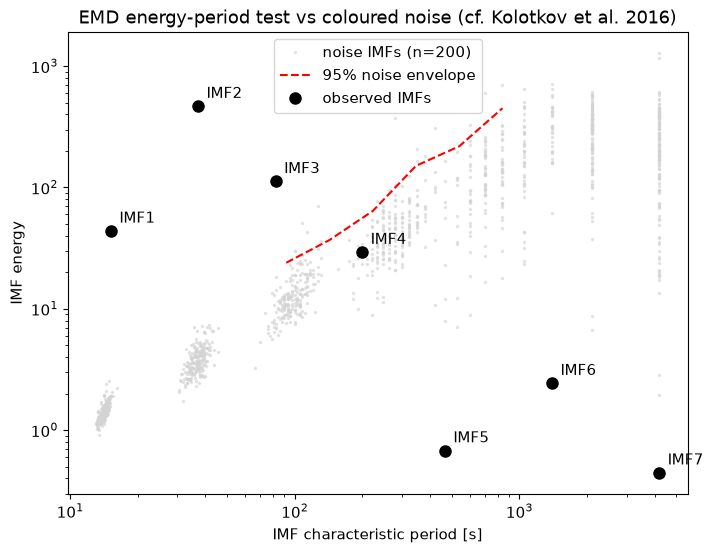

In [25]:
fig, ax = plt.subplots(figsize=[8, 6])
ax.loglog(mc_p, mc_e, '.', color='lightgrey', ms=3, alpha=0.5, label=f'noise IMFs (n={n_mc})')
ax.loglog(pcent, env95, 'r--', lw=1.5, label='95% noise envelope')
ax.loglog(imf_periods, imf_energies, 'ko', ms=8, label='observed IMFs')
for p_i, e_i, k in zip(imf_periods, imf_energies, range(len(imfs))):
    ax.annotate(f'IMF{k + 1}', (p_i, e_i), textcoords='offset points', xytext=[6, 6])
ax.set_xlabel('IMF characteristic period [s]')
ax.set_ylabel('IMF energy')
ax.set_title('EMD energy-period test vs coloured noise (cf. Kolotkov et al. 2016)')
ax.legend()
savefig(fig, 'stix_emd_significance')
plt.show()

### 5.3 Robustness of the period against the detrend window

The headline period must not be an artefact of one smoothing choice.

In [26]:
windows = [60, 90, 120, 180, 240]
rows = []
for w in tqdm(windows, desc='Detrend-window scan'):
    _, _, _, res_w, _ = qpp_residual(t_nt, r_nt, window_s=w, polyorder=3, dt_s=4)
    f_w, p_w = periodogram(res_w, 4)
    popt_w, _ = fit_rednoise(freqs_raw, power_raw)
    _, confs_w = confidence_levels(f_w, popt_w, len(f_w))
    ok = p_w > confs_w['global_0.95']
    dom = 1 / f_w[ok][np.argmax(p_w[ok])] if ok.any() else np.nan
    rows.append({'window_s': w, 'dominant_period_s': round(float(dom), 1) if np.isfinite(dom) else np.nan,
                 'n_sig_peaks': int(ok.sum())})

robust_df = pd.DataFrame(rows)
robust_df.to_csv(f'{res_dir}/qpp_window_robustness.csv', index=False)
robust_df

Detrend-window scan: 100%|██████████| 5/5 [00:00<00:00, 459.01it/s]


,window_s,dominant_period_s,n_sig_peaks
0,60,8.6,1
1,90,8.6,1
2,120,66.5,6
3,180,66.5,5
4,240,136.7,8


Repeat §4-§5 for the 50–84 keV band (and 15–25 keV for the thermal response) by changing
`band_nt` above and re-running — the STIX QPP result is the pair (period, band dependence).

## 6. One rhythm, many messengers: EOVSA, OVRO-LWA, GOES derivative

EOVSA peaked near 1000 sfu with multiple pulsation signatures (Bin); OVRO-LWA provides the
metric dynamic spectrum and ~10 s imaging (Peijin). Cadences differ (EOVSA ~1 s, STIX 4 s,
LWA 10 s), so everything is compared on a common 10 s grid — the LWA cadence is the binding
constraint (Shilpi's caution), and no cross-instrument claim is made below ~20 s periods.

File formats below follow the shared products; run the `inspect_*` helpers first and adjust
the reader once the Google Drive files are in place.

In [27]:
def inspect_fits(path):
    with fits.open(path) as hdul:
        hdul.info()
        for i, hdu in enumerate(hdul):
            print(f'--- HDU {i} header keys ---')
            print(repr(hdu.header)[:2000])


def load_eovsa_spectrogram(path):
    """
    EOVSA total-power dynamic spectrum FITS (as distributed by the OVSA team).
    Expected layout: primary data (nfreq, ntime), a frequency HDU/column in GHz and a
    time HDU/column (mjd or seconds). Adjust after inspect_fits().
    """
    with fits.open(path) as hdul:
        spec = hdul[0].data
        fghz = hdul[1].data['sfreq'] if 'sfreq' in hdul[1].columns.names else hdul[1].data.field(0)
        tmjd = hdul[2].data['mjd'] if 'mjd' in hdul[2].columns.names else hdul[2].data.field(0)
    t_index = pd.DatetimeIndex(Time(tmjd, format='mjd').datetime)
    return t_index, np.asarray(fghz), np.asarray(spec)


eovsa_file = f"{paths['eovsa']}/eovsa_dspec_20260118.fits"  # TODO: filename from Bin/Sijie
have_eovsa = os.path.exists(eovsa_file)
if have_eovsa:
    eov_t, eov_f, eov_s = load_eovsa_spectrogram(eovsa_file)
else:
    print('EOVSA spectrogram not on disk yet — section will skip until the file arrives')

EOVSA spectrogram not on disk yet — section will skip until the file arrives


In [28]:
def load_lwa_dyspec(path):
    """
    OVRO-LWA dynamic-spectrum FITS (Peijin's format):
    primary data (npol, 1, nfreq, ntime), 'SFREQ' HDU in GHz, 'UT' HDU with
    integer MJD plus milliseconds of day.
    Returns (time index, frequency [MHz], cube (npol, nfreq, ntime)).
    """
    with fits.open(path) as hdul:
        cube = hdul[0].data[:, 0, :, :]
        fmhz = hdul['SFREQ'].data['SFREQ'] * 1e3
        ut = hdul['UT'].data
        time_mjd = ut['mjd'] + ut['time'] / 86400000
    t_index = pd.DatetimeIndex(Time(time_mjd, format='mjd').to_datetime())
    return t_index, np.asarray(fmhz), np.asarray(cube)


lwa_file = f"{paths['lwa_dyspec']}/20260118.fits"
have_lwa = os.path.exists(lwa_file)
if have_lwa:
    lwa_t, lwa_f, lwa_cube = load_lwa_dyspec(lwa_file)
    print(f'{lwa_cube.shape[0]} polarisation planes, {len(lwa_f)} channels, {len(lwa_t)} time steps, '
          f'{lwa_f[0]:.1f}-{lwa_f[-1]:.1f} MHz')
    lwa_s = lwa_cube[0]  # first pol plane; confirm the plane ordering with Peijin
else:
    print('OVRO-LWA dynamic spectrum not on disk yet — section will skip until the file arrives')

2 polarisation planes, 731 channels, 53385 time steps, 15.0-84.9 MHz


In [29]:
def band_lightcurve(t_index, freqs, spec, f_lo, f_hi, window=None, bkg_window=None, log_ratio=True):
    """
    Frequency-averaged light curve in [f_lo, f_hi]. The per-channel background comes
    from bkg_window (quiet pre-flare interval); only the rows inside `window` are
    averaged, so the expensive part never runs on the full-day spectrogram.
    """
    sel_f = (freqs >= f_lo) & (freqs <= f_hi)
    if bkg_window is not None:
        bsel = (t_index >= pd.Timestamp(bkg_window[0])) & (t_index <= pd.Timestamp(bkg_window[1]))
        bkg = np.nanmedian(spec[np.ix_(sel_f, bsel)].astype(float), axis=1)[:, None]
    else:
        bkg = np.nanmedian(spec[sel_f, :].astype(float), axis=1)[:, None]
    if window is not None:
        wsel = (t_index >= window[0]) & (t_index <= window[1])
    else:
        wsel = np.ones(len(t_index), dtype=bool)
    sub = spec[np.ix_(sel_f, wsel)].astype(float)
    prof = np.nanmean(np.log10(sub / bkg), axis=0) if log_ratio else np.nanmean(sub - bkg, axis=0)
    return pd.Series(prof, index=t_index[wsel])


channels = {}
channels['STIX 25-50 keV'] = pd.Series(resid_n, index=grid_nt)

sx = sxr_deriv_smooth.loc[qpp_padded[0]:qpp_padded[1]].dropna()
g_g, _, _, _, rn_g = qpp_residual(sx.index, sx.values, window_s=120, polyorder=3, dt_s=4)
channels['GOES dSXR/dt'] = pd.Series(rn_g, index=g_g)

if have_eovsa:
    # GHz band = gyrosynchrotron core; only the padded QPP window is averaged
    eov_lc = band_lightcurve(eov_t, eov_f, eov_s, 3, 8, window=qpp_padded,
                             bkg_window=radio_bkg_window, log_ratio=False)
    g, _, _, _, rn = qpp_residual(eov_lc.index, eov_lc.values, window_s=120, polyorder=3, dt_s=1)
    channels['EOVSA 3-8 GHz'] = pd.Series(rn, index=g)

if have_lwa:
    # MHz band = type III range; only the padded QPP window is averaged
    lwa_lc = band_lightcurve(lwa_t, lwa_f, lwa_s, 30, 85, window=qpp_padded,
                             bkg_window=radio_bkg_window)
    g, _, _, _, rn = qpp_residual(lwa_lc.index, lwa_lc.values, window_s=120, polyorder=3, dt_s=10)
    channels['OVRO-LWA 30-85 MHz'] = pd.Series(rn, index=g)

# common 10 s grid over the QPP window
common = pd.date_range(qpp_window[0], qpp_window[1], freq='10s')
X = pd.DataFrame({k: np.interp(mdates.date2num(common), mdates.date2num(v.index), v.values)
                  for k, v in channels.items()}, index=common)

saved .//2026-01-18/figures/cross_instrument_residuals.pdf|png


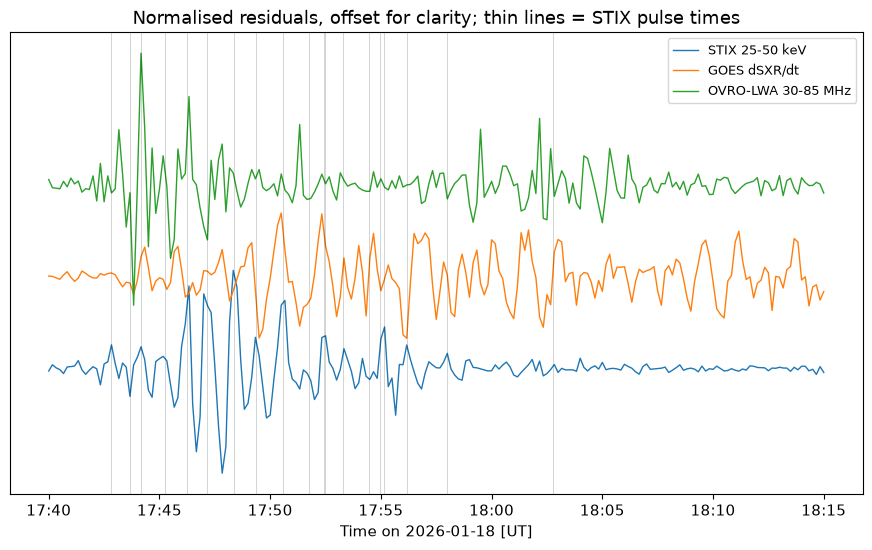

In [30]:
fig, ax = plt.subplots(figsize=[11, 6])
for i, col in enumerate(X.columns):
    ax.plot(X.index, standardise(X[col].values) + 4 * i, lw=1, label=col)
for tp in pulse_df['t_peak']:
    ax.axvline(tp, color='k', lw=0.4, alpha=0.3)
ax.set_yticks([])
ax.legend(loc='upper right', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel(f"Time on {event['date']} [UT]")
ax.set_title('Normalised residuals, offset for clarity; thin lines = STIX pulse times')
savefig(fig, 'cross_instrument_residuals')
plt.show()

saved .//2026-01-18/figures/cross_correlation_lags.pdf|png


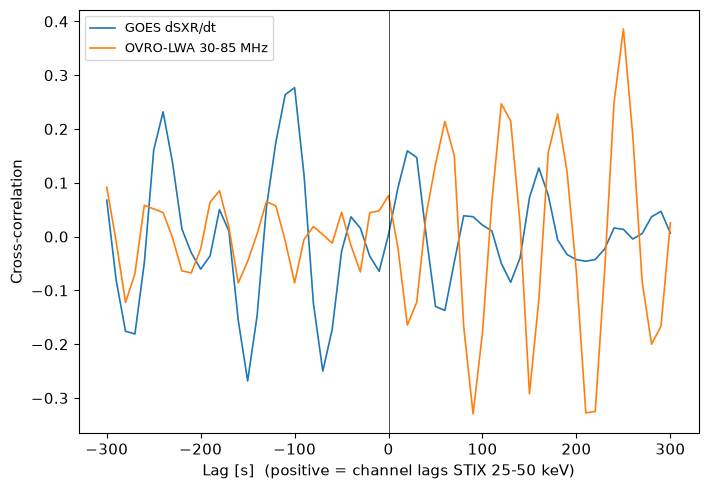

,channel,peak_lag_s,peak_cc
0,GOES dSXR/dt,-100,0.28
1,OVRO-LWA 30-85 MHz,250,0.39


In [31]:
def xcorr(a, b, dt_s, max_lag_s=300):
    a = standardise(np.nan_to_num(a))
    b = standardise(np.nan_to_num(b))
    cc = correlate(a, b, mode='full') / len(a)
    lags = np.arange(-len(a) + 1, len(a)) * dt_s
    sel = np.abs(lags) <= max_lag_s
    return lags[sel], cc[sel]


ref = 'STIX 25-50 keV'
fig, ax = plt.subplots(figsize=[8, 5.5])
lag_rows = []
for col in [c for c in X.columns if c != ref]:
    lags, cc = xcorr(X[ref].values, X[col].values, 10)
    ax.plot(lags, cc, lw=1.2, label=col)
    lag_pk = lags[np.argmax(cc)]
    lag_rows.append({'channel': col, 'peak_lag_s': int(lag_pk), 'peak_cc': round(float(np.max(cc)), 2)})
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel(f'Lag [s]  (positive = channel lags {ref})')
ax.set_ylabel('Cross-correlation')
ax.legend(fontsize=9)
savefig(fig, 'cross_correlation_lags')
plt.show()

lag_df = pd.DataFrame(lag_rows)
lag_df.to_csv(f'{res_dir}/cross_correlation_lags.csv', index=False)
lag_df

Beyond lags, run §5's periodogram/wavelet per channel and collect a **period comparison
table** — one period per channel with uncertainty (half-width of the significant peak).
Wavelet coherence (`pycwt.wct`) between STIX and EOVSA is the natural follow-up once the
EOVSA file is in hand; interpret only outside the COI and above the 95% level.

In [32]:
period_rows = []
for col in X.columns:
    f_c, p_c = periodogram(np.nan_to_num(X[col].values), 10)
    try:
        popt_c, _ = fit_rednoise(f_c, p_c)
        _, confs_c = confidence_levels(f_c, popt_c, len(f_c))
        ok = p_c > confs_c['global_0.95']
        dom = 1 / f_c[ok][np.argmax(p_c[ok])] if ok.any() else np.nan
    except RuntimeError:
        dom = np.nan
    period_rows.append({'channel': col, 'dominant_period_s': round(float(dom), 1) if np.isfinite(dom) else np.nan})

period_df = pd.DataFrame(period_rows)
period_df.to_csv(f'{res_dir}/period_comparison.csv', index=False)
period_df

,channel,dominant_period_s
0,STIX 25-50 keV,65.9
1,GOES dSXR/dt,95.9
2,OVRO-LWA 30-85 MHz,60.3


## 7. Type III bursts: timing against HXR pulses, polarisation, imaging

### 7.1 Burstiness of acceleration: type III occurrence vs STIX peaks (Shilpi)

Type III times from the frequency-collapsed LWA profile; matching tolerance is set by the
10 s LWA cadence, so association is claimed at ±15 s and treated as indicative, not exact.

19 type IIIs; 42% matched to an HXR pulse within ±15 s
saved .//2026-01-18/figures/typeIII_vs_hxr_timing.pdf|png


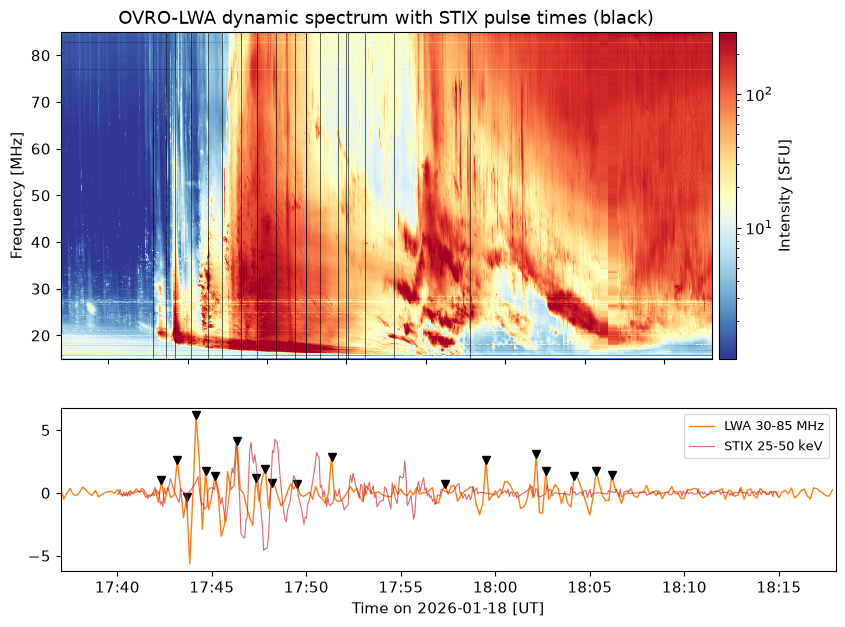

In [33]:
if have_lwa:
    lwa_prof = channels['OVRO-LWA 30-85 MHz']
    t3_idx, t3_props = find_peaks(lwa_prof.values, prominence=1.5, distance=2)
    t3_times = lwa_prof.index[t3_idx]

    tol = pd.Timedelta(seconds=15)
    matches = []
    for t3 in t3_times:
        d = (pulse_df['t_peak'] - t3).abs()
        j = d.idxmin()
        matches.append({'t_typeIII': t3, 't_hxr': pulse_df.loc[j, 't_peak'],
                        'dt_s': (pulse_df.loc[j, 't_peak'] - t3).total_seconds(),
                        'matched': d.min() <= tol})
    match_df = pd.DataFrame(matches)
    match_df.to_csv(f'{res_dir}/typeIII_hxr_matches.csv', index=False)
    frac = match_df['matched'].mean()
    print(f'{len(t3_times)} type IIIs; {frac:.0%} matched to an HXR pulse within ±15 s')
    results['typeIII_hxr_match_frac'] = round(float(frac), 2)

    wp = (lwa_t >= qpp_padded[0]) & (lwa_t <= qpp_padded[1])
    lwa_sw = lwa_s[:, wp]

    fig, axs = plt.subplots(2, 1, figsize=[10, 7], sharex=True, height_ratios=[2, 1])
    dys = axs[0].pcolormesh(lwa_t[wp], lwa_f, lwa_sw,
                            norm=colors.LogNorm(vmin=np.nanpercentile(lwa_sw, 5),
                                                vmax=np.nanpercentile(lwa_sw, 99)),
                            cmap='RdYlBu_r')
    fig.colorbar(dys, ax=axs[0], pad=0.01, label='Intensity [SFU]')
    axs[0].set_ylabel('Frequency [MHz]')
    axs[0].set_title('OVRO-LWA dynamic spectrum with STIX pulse times (black)')
    for tp in pulse_df['t_peak']:
        axs[0].axvline(tp, color='k', lw=0.6, alpha=0.7)

    axs[1].plot(lwa_prof.index, lwa_prof.values, lw=1, color='tab:orange', label='LWA 30-85 MHz')
    axs[1].plot(t3_times, lwa_prof.values[t3_idx], 'kv', ms=6)
    axs[1].plot(grid_nt, resid_n, lw=0.8, color='tab:red', alpha=0.7, label='STIX 25-50 keV')
    axs[1].legend(fontsize=9)
    axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axs[1].set_xlabel(f"Time on {event['date']} [UT]")
    savefig(fig, 'typeIII_vs_hxr_timing')
    plt.show()

### 7.2 Type III polarisation (LWA Stokes V/I)

Sense and degree of circular polarisation across the type III group constrain the magnetic
field orientation along the beam paths — o-mode dominance is the expectation; changes of
sign across bursts would point to distinct source regions or field geometries. That reading
is a hypothesis to test against the imaging in §7.3.

saved .//2026-01-18/figures/typeIII_polarisation.pdf|png


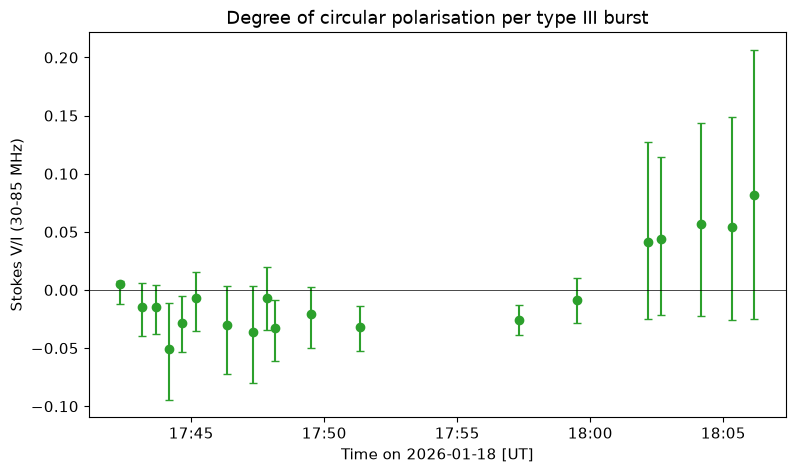

In [35]:
# The polarisation planes live on the first axis of the same dspec cube.
# TODO: confirm the plane ordering with Peijin (assumed here: plane 0 = Stokes I,
# plane 1 = Stokes V); the V sign convention decides o-mode vs x-mode.
if have_lwa and lwa_cube.shape[0] >= 2:
    lwa_tw = lwa_t[wp]
    dcp = lwa_cube[1][:, wp] / lwa_cube[0][:, wp]

    rows = []
    for t3 in t3_times:
        w = (lwa_tw >= t3 - pd.Timedelta(seconds=10)) & (lwa_tw <= t3 + pd.Timedelta(seconds=20))
        band = (lwa_f >= 30) & (lwa_f <= 85)
        box = dcp[np.ix_(band, w)]
        rows.append({'t_typeIII': t3, 'dcp_mean': float(np.nanmean(box)),
                     'dcp_p16': float(np.nanpercentile(box, 16)),
                     'dcp_p84': float(np.nanpercentile(box, 84))})
    dcp_df = pd.DataFrame(rows)
    dcp_df.to_csv(f'{res_dir}/typeIII_polarisation.csv', index=False)

    fig, ax = plt.subplots(figsize=[9, 5])
    ax.errorbar(dcp_df['t_typeIII'], dcp_df['dcp_mean'],
                yerr=[dcp_df['dcp_mean'] - dcp_df['dcp_p16'], dcp_df['dcp_p84'] - dcp_df['dcp_mean']],
                fmt='o', color='tab:green', capsize=3)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel('Stokes V/I (30-85 MHz)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_xlabel(f"Time on {event['date']} [UT]")
    ax.set_title('Degree of circular polarisation per type III burst')
    savefig(fig, 'typeIII_polarisation')
    plt.show()
else:
    print('dspec cube has a single polarisation plane — ask Peijin for the Stokes V product')

### 7.3 LWA imaging: source centroids on the AIA disc

~10 s cadence imaging FITS (Peijin's Google Drive). Centroids above a threshold trace the
type III trajectories; Catherine's uncertainty map bounds where triangulation with a second
array would be viable. Positions at these frequencies carry ionospheric + scattering shifts
— treat absolute positions with care, relative motion is the robust quantity.

In [36]:
lwa_img_files = sorted(glob.glob(f"{paths['lwa_imaging']}/*.fits"))
print(f'{len(lwa_img_files)} LWA imaging files')
if lwa_img_files:
    inspect_fits(lwa_img_files[0])

0 LWA imaging files


In [37]:
def lwa_image_centroids(files, thresh_frac=0.7):
    """
    Brightest-pixel + intensity-weighted centroid per file (per frequency plane if 3D).
    Returns a tidy DataFrame; coordinates in the file's native WCS (arcsec if helioprojective).
    """
    rows = []
    for fname in tqdm(files, desc='LWA images'):
        with fits.open(fname) as hdul:
            hdu = hdul[0]
            data = np.squeeze(hdu.data)
            hdr = hdu.header
            tobs = pd.Timestamp(hdr.get('DATE-OBS', hdr.get('DATE_OBS')))
            planes = data[None, ...] if data.ndim == 2 else data
            for k, img in enumerate(planes):
                if not np.isfinite(img).any():
                    continue
                pk = np.nanmax(img)
                ys, xs = np.where(img >= thresh_frac * pk)
                wts = img[ys, xs]
                cx = np.sum(xs * wts) / np.sum(wts)
                cy = np.sum(ys * wts) / np.sum(wts)
                x_world = hdr['CRVAL1'] + (cx + 1 - hdr['CRPIX1']) * hdr['CDELT1']
                y_world = hdr['CRVAL2'] + (cy + 1 - hdr['CRPIX2']) * hdr['CDELT2']
                rows.append({'time': tobs, 'plane': k, 'x': x_world, 'y': y_world, 'peak': pk})
    return pd.DataFrame(rows)


if lwa_img_files:
    cen_df = lwa_image_centroids(lwa_img_files)
    cen_df.to_csv(f'{res_dir}/lwa_centroids.csv', index=False)

In [38]:
# AIA context frame near the flare peak for the overlay
aia_query = Fido.search(a.Time(event['flare_peak'], pd.Timestamp(event['flare_peak']) + pd.Timedelta(minutes=2)),
                        a.Instrument('AIA'), a.Wavelength(171 * u.angstrom), a.Sample(1 * u.min))
aia_files = Fido.fetch(aia_query, path=f"{paths['aia']}/{{file}}")
m_aia = sunpy.map.Map(sorted(aia_files)[0])

if lwa_img_files:
    fig = plt.figure(figsize=[8, 8])
    ax = fig.add_subplot(projection=m_aia)
    m_aia.plot(axes=ax, clip_interval=(1, 99.9) * u.percent)
    sc = ax.scatter_coord(SkyCoord(cen_df['x'].values * u.arcsec, cen_df['y'].values * u.arcsec,
                                   frame=m_aia.coordinate_frame),
                          c=mdates.date2num(cen_df['time']), cmap='cool', s=25, edgecolor='k', lw=0.3)
    cbar = plt.colorbar(sc, ax=ax, shrink=0.8, label='Time [UT]')
    cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_title('OVRO-LWA source centroids on AIA 171 Å')
    savefig(fig, 'lwa_centroids_on_aia')
    plt.show()

Files Downloaded:   0%|          | 0/2 [00:00<?, ?file/s]

## 8. CME kinematics and shock formation

Height-time points from LASCO C2/C3 and STEREO-A/COR2 (CDAW catalogue values, or your own
tie-points/GCS fits — replace the placeholder table). The near-Sun acceleration phase is
what matters for the SEP question: when does the CME reach the speed/height at which the
type II appears, and how does that time sit relative to the QPP interval and the inferred
particle release (§10)?

For a halo near central meridian the LASCO plane-of-sky speed is a projection — the
STEREO-A vantage and a GCS fit give the deprojected speed; ESA's transit estimate
(~1700 km/s) is a consistency check, not a measurement of the near-Sun speed.

In [39]:
# TODO: replace with measured points (CDAW: https://cdaw.gsfc.nasa.gov/CME_list/)
# columns: UT time, height [Rsun], instrument
ht_rows = [
    # ('2026-01-18T18:24:00', 3.1, 'C2'),
    # ('2026-01-18T18:36:00', 5.6, 'C2'),
    # ('2026-01-18T18:48:00', 8.4, 'C3'),
]
have_ht = len(ht_rows) > 0

if have_ht:
    ht = pd.DataFrame(ht_rows, columns=['time', 'height_rsun', 'inst'])
    ht['time'] = pd.to_datetime(ht['time'])
    tsec_cme, t0_cme = to_seconds(ht['time'])
    h_mm = ht['height_rsun'].values * const.R_sun.to_value(u.Mm)
else:
    print('CME height-time table empty — fill ht_rows to run §8')

CME height-time table empty — fill ht_rows to run §8


In [40]:
def kinematic_model(t, s0, v0, acc):
    return s0 + v0 * t + 0.5 * acc * t**2


def fit_kinematics(tsec, dist_mm, v0_max=3.5):
    """
    Constant-acceleration fit (as in solar_data_utils, bounds widened for this event:
    v0 up to 3500 km/s). Distances in Mm, times in s.
    """
    rsun_mm = const.R_sun.to_value(u.Mm)
    p0 = [2 * rsun_mm, 1, 0.0005]
    bounds = ([rsun_mm, 0.1, -0.005], [30 * rsun_mm, v0_max, 0.005])
    params, pcov = curve_fit(kinematic_model, tsec, dist_mm, p0=p0, bounds=bounds)
    perr = np.sqrt(np.diag(pcov))
    return params, perr


if have_ht:
    (s0_f, v0_f, a_f), (s0_e, v0_e, a_e) = fit_kinematics(tsec_cme, h_mm)
    print(f'v0 = {v0_f * 1e3:.0f} ± {v0_e * 1e3:.0f} km/s, a = {a_f * 1e6:.0f} ± {a_e * 1e6:.0f} m/s²')
    results['cme_v0_kms'] = round(float(v0_f * 1e3))
    results['cme_acc_ms2'] = round(float(a_f * 1e6))

    # model-independent check: Savitzky-Golay derivative of the height-time points
    if len(tsec_cme) >= 7:
        h_s = savgol_filter(h_mm, 5, 2)
        v_sg = np.gradient(h_s, tsec_cme) * 1e3  # km/s

    fig, axs = plt.subplots(2, 1, figsize=[9, 7], sharex=True)
    tfit = np.linspace(tsec_cme[0], tsec_cme[-1], 200)
    axs[0].plot(ht['time'], ht['height_rsun'], 'ko', label='height-time points')
    axs[0].plot(t0_cme + pd.to_timedelta(tfit, unit='s'),
                kinematic_model(tfit, s0_f, v0_f, a_f) / const.R_sun.to_value(u.Mm),
                'r-', lw=1.2, label='constant-a fit')
    axs[0].set_ylabel(r'Height [$R_\odot$]')
    axs[0].legend()

    axs[1].plot(t0_cme + pd.to_timedelta(tfit, unit='s'), (v0_f + a_f * tfit) * 1e3, 'r-', lw=1.2)
    axs[1].set_ylabel('Speed [km s$^{-1}$]')
    axs[1].axvspan(t_flare['flare_onset'], t_flare['flare_end'], color='gold', alpha=0.15)
    axs[1].axvline(t_flare['type_iv_onset'], color='tab:blue', lw=1, ls='--', label='type IV onset')
    axs[1].legend()
    axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axs[1].set_xlabel(f"Time on {event['date']} [UT]")
    savefig(fig, 'cme_kinematics')
    plt.show()

### 8.1 Type II drift rate → shock speed, and band-splitting diagnostics

Coronal electron-density models convert the type II frequency drift into a radial shock
speed. With $f_{pe}\,[\mathrm{kHz}] = 8.98\sqrt{n_e\,[\mathrm{cm^{-3}}]}$ (fundamental;
divide traced frequencies by 2 for the harmonic lane):

$$ v_{sh} = \frac{df/dt}{df/dr} , \qquad \frac{df}{dr} = \frac{f}{2 n_e}\frac{dn_e}{dr} $$

Band splitting (Vršnak et al. 2001, 2002): the upstream/downstream interpretation gives the
density jump $X = (f_U/f_L)^2$ and, for a perpendicular low-β shock,

$$ M_A = \sqrt{\frac{X(X+5)}{2(4-X)}} , \qquad v_A = v_{sh}/M_A $$

and the coronal field from $B\,[\mathrm{G}] = 5.1\times10^{-5} f\,[\mathrm{MHz}]\; v_A\,[\mathrm{km\,s^{-1}}]$
(Gopalswamy & Yashiro 2011). The geometry assumption is a caveat to state, not a fact.

In [41]:
def n_newkirk(r, fold=1):
    return fold * 4.2e4 * 10**(4.32 / r)


def n_saito(r):
    return 1.36e6 * r**-2.14 + 1.68e8 * r**-6.13


def n_leblanc(r):
    return 3.3e5 * r**-2 + 4.1e6 * r**-4 + 8e7 * r**-6


density_models = {'Newkirk': n_newkirk, 'Saito': n_saito, 'Leblanc': n_leblanc}


def freq_to_radius(f_mhz, model, harmonic=False):
    f_fund = f_mhz / 2 if harmonic else f_mhz
    func = lambda r: 8.98e-3 * np.sqrt(model(r)) - f_fund
    return float(fsolve(func, 1.5)[0])


def shock_speed_from_drift(f_mhz, dfdt_mhz_s, model, harmonic=False):
    """v_sh in km/s from the local drift rate at frequency f_mhz."""
    r = freq_to_radius(f_mhz, model, harmonic)
    dr = 1e-4
    dfdr = (8.98e-3 * np.sqrt(model(r + dr)) - 8.98e-3 * np.sqrt(model(r - dr))) / (2 * dr)  # MHz/Rsun
    v_rsun_s = dfdt_mhz_s / dfdr
    return r, v_rsun_s * const.R_sun.to_value(u.km)


# TODO: trace the type II lane(s) (two (t, f) points or a CSV export from your dyspec tracer)
typeii_trace = {
    'f1_mhz': None, 't1': None,   # e.g. 80, '2026-01-18T17:52:00'
    'f2_mhz': None, 't2': None,
    'harmonic': True,
}

if typeii_trace['f1_mhz'] is not None:
    dt_drift = (pd.Timestamp(typeii_trace['t2']) - pd.Timestamp(typeii_trace['t1'])).total_seconds()
    dfdt = (typeii_trace['f2_mhz'] - typeii_trace['f1_mhz']) / dt_drift
    f_mid = 0.5 * (typeii_trace['f1_mhz'] + typeii_trace['f2_mhz'])
    rows = []
    for name, model in density_models.items():
        r_mid, v_sh = shock_speed_from_drift(f_mid, dfdt, model, typeii_trace['harmonic'])
        rows.append({'model': name, 'r_mid_rsun': round(r_mid, 2), 'v_shock_kms': round(v_sh)})
    drift_df = pd.DataFrame(rows)
    drift_df.to_csv(f'{res_dir}/typeii_drift_speeds.csv', index=False)
    print(drift_df)
    print(f"reported RSTN drift speed for comparison: {event['type_ii_drift_speed_reported']} km/s")

In [42]:
def band_split_diagnostics(f_lower_mhz, f_upper_mhz, v_shock_kms, model=n_newkirk, harmonic=True):
    """Density jump, Alfvén Mach number, Alfvén speed, and B at the emission height."""
    X = (f_upper_mhz / f_lower_mhz)**2
    M_A = np.sqrt(X * (X + 5) / (2 * (4 - X)))
    v_A = v_shock_kms / M_A
    f_fund = (f_lower_mhz / 2 if harmonic else f_lower_mhz)
    B = 5.1e-5 * f_fund * v_A
    r_emit = freq_to_radius(f_lower_mhz, model, harmonic)
    return {'X': round(X, 2), 'M_A': round(M_A, 2), 'v_A_kms': round(v_A),
            'B_gauss': round(B, 2), 'r_rsun': round(r_emit, 2)}


# TODO: simultaneous upper/lower band frequencies from the traced lanes
# example call once measured:
# bs = band_split_diagnostics(f_lower_mhz=60, f_upper_mhz=68, v_shock_kms=drift_df['v_shock_kms'].mean())
# results.update({f'typeii_{k}': v for k, v in bs.items()})

Shock-formation timing synthesis: compare (i) type II onset time, (ii) the height where the
fitted CME speed first exceeds the local fast-mode speed (needs $v_A(r)$ from the model
above), and (iii) the type IV onset (18:13 UT). CASHeW-style shock characterisation
(Kozarev et al.) on the AIA off-limb sector is the follow-up once the EUV wave front is
traced — the `plot_jmap` pipeline slots in here unchanged.

## 9. Magnetic connectivity and spacecraft geometry

This section settles the abstract's open caveat — Solar Orbiter's actual vantage — before
any EPD claim is made, then estimates which observers were magnetically connected to
AR 4341 / the shock.

In [43]:
solo_coord = get_horizons_coord('Solar Orbiter', event['flare_peak'])
sta_coord = get_horizons_coord('STEREO-A', event['flare_peak'])
psp_coord = get_horizons_coord('Parker Solar Probe', event['flare_peak'])

for name, c in zip(['Solar Orbiter', 'STEREO-A', 'PSP'], [solo_coord, sta_coord, psp_coord]):
    ch = c.transform_to(sunpy.coordinates.HeliographicStonyhurst(obstime=event['flare_peak']))
    print(f'{name}: r = {ch.radius.to_value(u.au):.3f} au, lon = {ch.lon.to_value(u.deg):+.1f}°, '
          f'lat = {ch.lat.to_value(u.deg):+.1f}° (Stonyhurst)')
    results[f'{name.replace(" ", "_")}_r_au'] = round(float(ch.radius.to_value(u.au)), 3)
    results[f'{name.replace(" ", "_")}_lon_deg'] = round(float(ch.lon.to_value(u.deg)), 1)

Solar Orbiter: r = 0.745 au, lon = +8.2°, lat = -2.0° (Stonyhurst)
STEREO-A: r = 0.964 au, lon = +51.5°, lat = -7.3° (Stonyhurst)
PSP: r = 0.716 au, lon = -157.3°, lat = +3.5° (Stonyhurst)


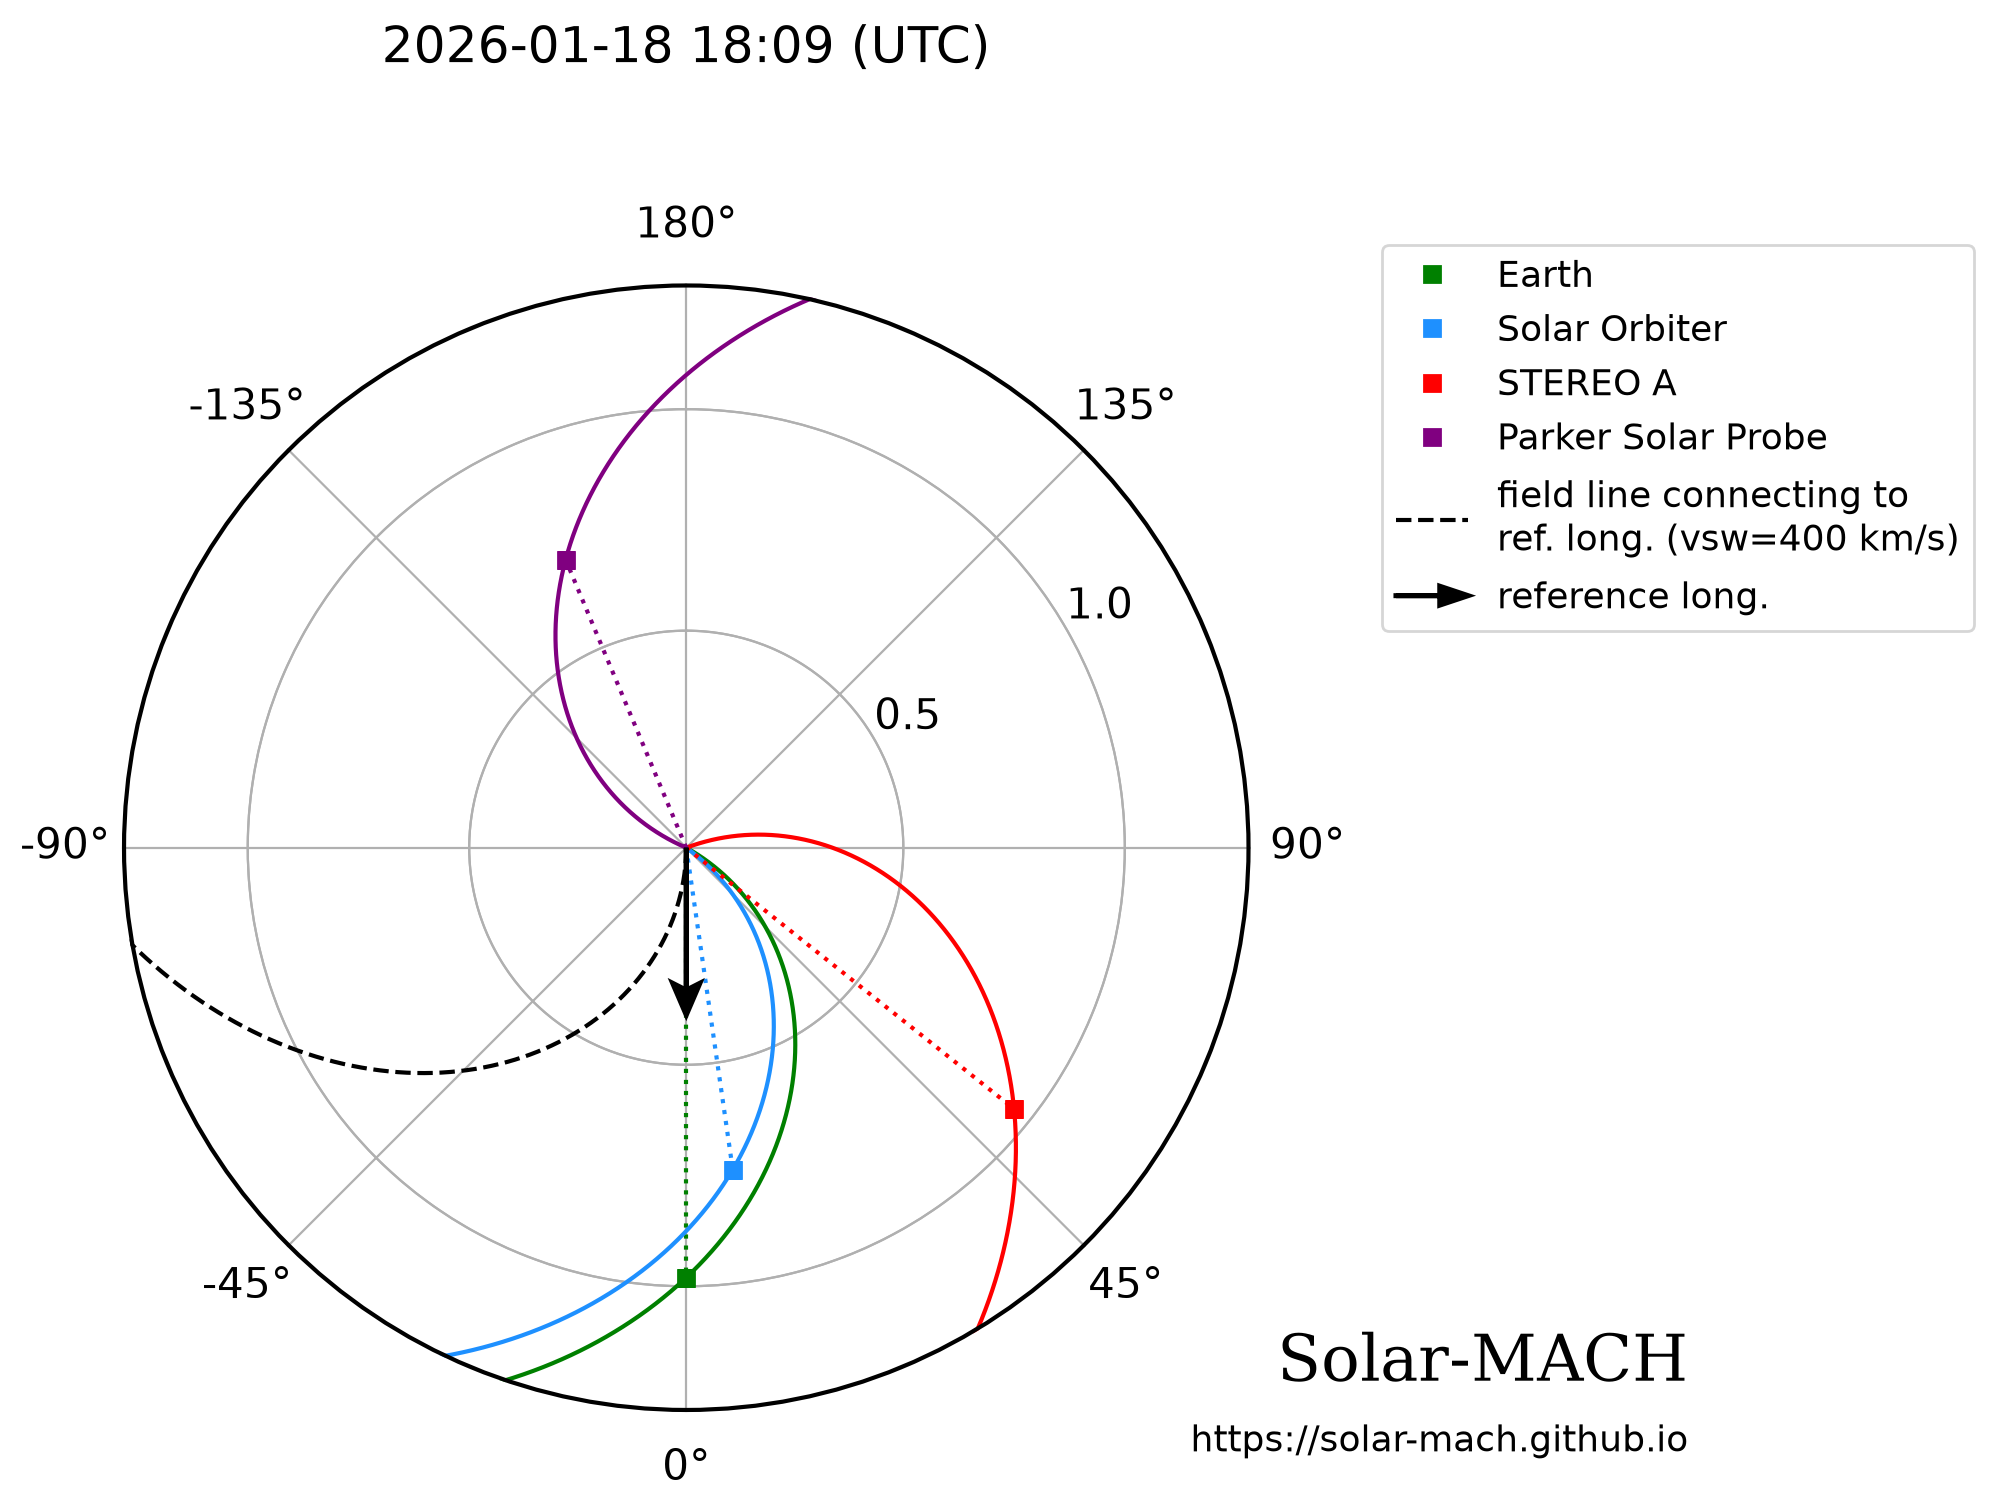

,Spacecraft/Body,Stonyhurst longitude (°),Stonyhurst latitude (°),Heliocentric distance (AU),Longitudinal separation to Earth's longitude,Latitudinal separation to Earth's latitude,Vsw,Magnetic footpoint longitude (Stonyhurst),Longitudinal separation between body and reference_long,Longitudinal separation between body's magnetic footpoint and reference_long,Latitudinal separation between body and reference_lat
0,Earth,-5.007420e-07,-4.897938,0.983934,0.000000,0.000000,400,61.152221,-5.007420e-07,61.152221,-4.897938
1,Solar Orbiter,8.217488e+00,-2.041060,0.744673,8.217489,2.856879,400,54.624086,8.217488e+00,54.624086,-2.041060
2,STEREO-A,5.145101e+01,-7.323331,0.964030,51.451012,-2.425392,400,110.983458,5.145101e+01,110.983458,-7.323331
3,Parker Solar Probe,-1.572737e+02,3.518829,0.716334,-157.273718,8.416767,400,-112.722133,-1.572737e+02,-112.722133,3.518829


In [44]:
from solarmach import SolarMACH

# AR 4341 was near central meridian as seen from Earth; refine flare_lon/lat from an HMI/AIA
# flare-ribbon fix when available
flare_lon_stonyhurst = 0   # TODO: refine [deg]
flare_lat = 0              # TODO: refine [deg]

body_list = ['Earth', 'Solar Orbiter', 'STEREO-A', 'Parker Solar Probe']
vsw_list = [400, 400, 400, 400]  # TODO: measured solar-wind speeds per observer

sm = SolarMACH(event['flare_peak'], body_list, vsw_list,
               reference_long=flare_lon_stonyhurst, reference_lat=flare_lat,
               coord_sys='Stonyhurst')
sm.plot(plot_spirals=True, plot_sun_body_line=True, reference_vsw=400,
        outfile=f'{fig_dir}/solarmach_geometry.png')
sm.coord_table

In [45]:
sm.coord_table.to_csv(f'{res_dir}/spacecraft_geometry.csv', index=False)
# separation between each observer's Parker footpoint and the flare longitude:
# the standard first-order connectivity measure for interpreting SEP onset delays
if 'Magnetic footpoint longitude (Stonyhurst)' in sm.coord_table.columns:
    fp = sm.coord_table['Magnetic footpoint longitude (Stonyhurst)'].astype(float)
    sep_ang = (fp - flare_lon_stonyhurst + 180) % 360 - 180
    for body, s in zip(sm.coord_table.iloc[:, 0], sep_ang):
        print(f'{body}: footpoint-flare separation = {s:+.1f}°')

Earth: footpoint-flare separation = +61.2°
Solar Orbiter: footpoint-flare separation = +54.6°
STEREO-A: footpoint-flare separation = +111.0°
Parker Solar Probe: footpoint-flare separation = -112.7°


### 9.1 PFSS open-field map around AR 4341

GONG zero-corrected synoptic map → PFSS (source surface 2.5 $R_\odot$) → open field in the
AR neighbourhood. This tells us whether flare-accelerated electrons had direct access to
open field (relevant for the type III groups and the prompt electron onset), independent of
the shock. Interpretation stays qualitative: PFSS is a potential-field approximation taken
during a highly non-potential interval.

In [47]:
try:
    from sunkit_magex import pfss as pfss_pkg
    from sunkit_magex.pfss import tracing
except ImportError:
    import pfsspy as pfss_pkg
    from pfsspy import tracing

gong_query = Fido.search(a.Time('2026-01-18T00:00:00', '2026-01-18T17:00:00'), a.Instrument('GONG'))
gong_files = Fido.fetch(gong_query[0, -1], path=f"{paths['gong']}/{{file}}")
m_gong = sunpy.map.Map(gong_files[0])

pfss_in = pfss_pkg.Input(m_gong, nr=35, rss=2.5)
pfss_out = pfss_pkg.pfss(pfss_in)

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

21/121 field lines open within ±15° of the flare site
saved .//2026-01-18/figures/pfss_open_field.pdf|png


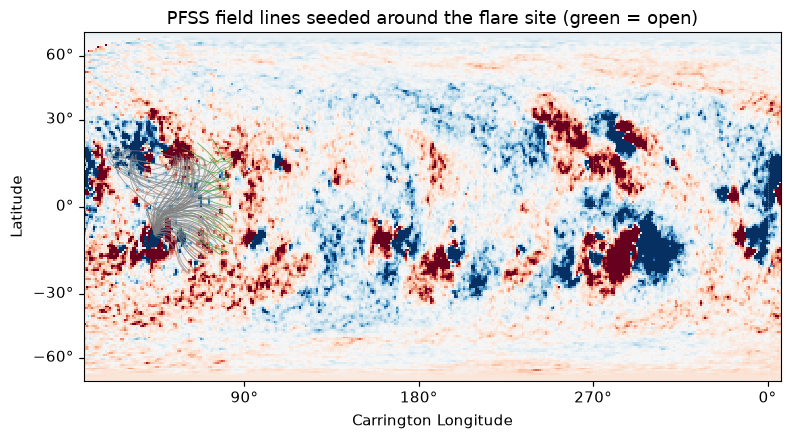

In [48]:
try:
    tracer = tracing.PerformanceTracer()
except AttributeError:
    tracer = tracing.FortranTracer()

# seed a grid around the flare site at 1.1 Rsun
lons = np.deg2rad(np.arange(flare_lon_stonyhurst - 15, flare_lon_stonyhurst + 16, 3))
lats = np.deg2rad(np.arange(flare_lat - 15, flare_lat + 16, 3))
lon2, lat2 = np.meshgrid(lons, lats)
seeds = SkyCoord(lon2.ravel() * u.rad, lat2.ravel() * u.rad, 1.1 * const.R_sun,
                 frame=sunpy.coordinates.HeliographicStonyhurst(obstime=m_gong.date))
flines = tracer.trace(seeds, pfss_out)

n_open = sum(1 for f in flines.field_lines if f.is_open)
print(f'{n_open}/{len(flines.field_lines)} field lines open within ±15° of the flare site')
results['open_fraction_ar'] = round(n_open / len(flines.field_lines), 2)

fig = plt.figure(figsize=[9, 7])
ax = fig.add_subplot(projection=m_gong)
m_gong.plot(axes=ax, cmap='RdBu_r', norm=colors.Normalize(vmin=-20, vmax=20))
for f in flines.field_lines:
    color = 'tab:green' if f.is_open else 'grey'
    coords = f.coords.transform_to(m_gong.coordinate_frame)
    ax.plot_coord(coords, color=color, lw=0.6, alpha=0.7)
ax.set_title('PFSS field lines seeded around the flare site (green = open)')
savefig(fig, 'pfss_open_field')
plt.show()

## 10. SEPs: onsets, velocity dispersion, and release times

The chain closes here: do the inferred release times of protons (GOES) and electrons
(Solar Orbiter/EPD, if connectivity supports it) fall inside the QPP interval, on the type
III groups, or later with the developing shock? VDA assumptions (common release, identical
path length, scatter-free first arrival) bias release times late at low energies — say so
when quoting results.

In [49]:
def fetch_goes_sgps(day, sat=18):
    """GOES-R SGPS L2 5-min proton fluxes from NOAA NCEI (version string discovered live)."""
    y = day[:4]
    m = day[5:7]
    d = day.replace('-', '')
    base = (f'https://data.ngdc.noaa.gov/platforms/solar-space-observing-satellites/'
            f'goes/goes{sat}/l2/data/sgps-l2-avg5m/{y}/{m}/')
    from bs4 import BeautifulSoup
    soup = BeautifulSoup(requests.get(base).text, 'html.parser')
    fname = next((a_.get('href') for a_ in soup.find_all('a')
                  if a_.get('href', '').endswith('.nc') and f'd{d}' in a_.get('href')), None)
    if fname is None:
        raise FileNotFoundError(f'no SGPS file for {day} at {base}')
    local = f"{paths['sep']}/{fname}"
    if not os.path.exists(local):
        open(local, 'wb').write(requests.get(base + fname).content)
    return local


import xarray as xr

sgps_files = [fetch_goes_sgps(d) for d in ['2026-01-18', '2026-01-19', '2026-01-20']]
sgps = xr.open_mfdataset(sgps_files, combine='by_coords')
print(list(sgps.data_vars))

['L1bRecordsInAvg', 'yaw_flip_flag', 'AvgDiffProtonFlux', 'AvgDiffProtonFluxObserved', 'AvgDiffProtonFluxUncert', 'DiffValidL1bSamplesInAvg', 'DiffDQFdtcSum', 'DiffDQFoobSum', 'DiffDQFerrSum', 'AvgIntProtonFlux', 'AvgIntProtonFluxObserved', 'AvgIntProtonFluxUncert', 'IntValidL1bSamplesInAvg', 'IntDQFdtcSum', 'IntDQFoobSum', 'IntDQFerrSum', 'DiffProtonLowerEnergy', 'DiffProtonUpperEnergy', 'DiffProtonEffectiveEnergy', 'IntegralProtonEffectiveEnergy', 'ExpectedLUTNotFound', 'AvgDiffAlphaFlux', 'AvgDiffAlphaFluxObserved', 'AvgDiffAlphaFluxUncert', 'DiffAlphaLowerEnergy', 'DiffAlphaUpperEnergy', 'DiffAlphaEffectiveEnergy', 'DiffProtonIgnoredL1bDQFs', 'IntProtonIgnoredL1bDQFs', 'DiffAlphaIgnoredL1bDQFs']


In [51]:
# Differential proton flux: keep (time, channel), collapse everything else
# (e.g. the two sensor units) with max = worst-case flux.
pvar = 'AvgDiffProtonFlux'
evar = 'DiffProtonEffectiveEnergy'
flux = sgps[pvar]
print(flux.dims, flux.shape)

keep = {'time'} | {d for d in flux.dims if 'channel' in d.lower()}
drop = [d for d in flux.dims if d not in keep]
if drop:
    flux = flux.max(dim=drop)

# effective energies: average over non-channel axes; SGPS stores them in keV
E_eff = sgps[evar].values
E_eff = np.nanmean(E_eff, axis=tuple(range(E_eff.ndim - 1)))
if np.nanmax(E_eff) > 1e3:
    E_eff = E_eff / 1e3
print('effective energies [MeV]:', np.round(E_eff, 1))

goes_p = flux.to_pandas()
goes_p.index = pd.DatetimeIndex(goes_p.index)

('time', 'sensor_units', 'diff_channels') (864, 2, 13)
effective energies [MeV]: [  1.4   2.1   2.8   4.7   8.   16.5  30.3  54.5  89.9 108.3 125.4 183.
 322.7]


In [52]:
def onset_time(series, bkg_window, n_sigma=3.5, n_consec=4):
    """
    Classic threshold onset: background mean+n_sigma*std from a quiet window; onset is the
    first of n_consec consecutive samples above threshold. Poisson-CUSUM (Huttunen-Heikinmaa
    et al. 2005) is the cross-check for weak channels.
    """
    bkg = series.loc[bkg_window[0]:bkg_window[1]]
    thr = bkg.mean() + n_sigma * bkg.std()
    above = series > thr
    run = above.rolling(n_consec).sum() == n_consec
    if not run.any():
        return pd.NaT, thr
    step = (series.index[1] - series.index[0]).total_seconds()
    return run.idxmax() - pd.Timedelta(seconds=(n_consec - 1) * step), thr


bkg_win = ('2026-01-18T06:00:00', '2026-01-18T16:00:00')
onset_rows = []
for j in tqdm(range(goes_p.shape[1]), desc='GOES proton onsets'):
    s = goes_p.iloc[:, j].dropna()
    t_on, thr = onset_time(s, bkg_win)
    onset_rows.append({'channel': j, 'E_mev': E_eff[j] if E_eff is not None else np.nan,
                       't_onset': t_on, 'threshold': thr, 'species': 'p', 'observer': 'GOES'})

onset_df = pd.DataFrame(onset_rows)
onset_df

GOES proton onsets: 100%|██████████| 13/13 [00:00<00:00, 720.73it/s]


,channel,E_mev,t_onset,threshold,species,observer
0,0,1.377392,2026-01-18 00:00:00,6.684697e-02,p,GOES
1,1,2.090485,2026-01-18 00:20:00,4.592372e-03,p,GOES
2,2,2.777674,2026-01-18 22:35:00,1.776704e-03,p,GOES
3,3,4.693895,2026-01-18 21:05:00,4.344078e-04,p,GOES
4,4,8.014999,2026-01-18 20:35:00,6.678978e-05,p,GOES
5,5,16.457993,2026-01-18 19:40:00,2.741438e-05,p,GOES
6,6,30.285967,2026-01-18 21:35:00,2.853786e-06,p,GOES
7,7,54.533249,2026-01-18 22:20:00,1.738942e-06,p,GOES
8,8,89.893288,2026-01-19 03:20:00,9.691402e-07,p,GOES
9,9,108.301834,2026-01-19 10:25:00,1.813948e-06,p,GOES


saved .//2026-01-18/figures/goes_proton_onsets.pdf|png


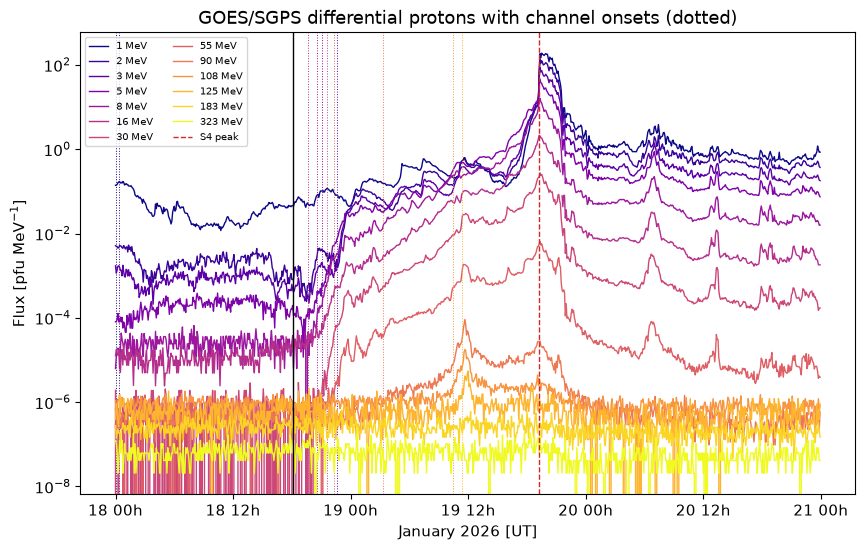

In [53]:
fig, ax = plt.subplots(figsize=[10, 6])
cols = plt.cm.plasma(np.linspace(0, 1, goes_p.shape[1]))
for j in range(goes_p.shape[1]):
    lbl = f'{E_eff[j]:.0f} MeV' if E_eff is not None else f'ch{j}'
    ax.plot(goes_p.index, goes_p.iloc[:, j], lw=1, color=cols[j], label=lbl)
    if pd.notna(onset_df.loc[j, 't_onset']):
        ax.axvline(onset_df.loc[j, 't_onset'], color=cols[j], lw=0.7, ls=':')
ax.set_yscale('log')
ax.set_ylabel(r'Flux [pfu MeV$^{-1}$]')
ax.axvline(t_flare['flare_peak'], color='k', lw=1)
ax.axvline(t_flare['sep_peak'], color='tab:red', lw=1, ls='--', label='S4 peak')
ax.legend(fontsize=7, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %Hh'))
ax.set_xlabel('January 2026 [UT]')
ax.set_title('GOES/SGPS differential protons with channel onsets (dotted)')
savefig(fig, 'goes_proton_onsets')
plt.show()

### 10.1 Solar Orbiter EPD (run only after §9 confirms the vantage)

In [55]:
run_epd = True
if run_epd:
    from solo_epd_loader import epd_load
    df_ion, df_ele, epd_meta = epd_load(sensor='ept', level='l2', startdate=20260118,
                                        enddate=20260120, viewing='sun',
                                        path=paths['sep'], autodownload=True)

    # channel energies from the numeric bin edges (both in MeV):
    # geometric mean of [E_low, E_low + width] — no text parsing
    E_low = np.asarray(epd_meta['Electron_Bins_Low_Energy'], dtype=float).ravel()
    E_wid = np.asarray(epd_meta['Electron_Bins_Width'], dtype=float).ravel()
    E_mev_bins = np.sqrt(E_low * (E_low + E_wid))

    ele = df_ele['Electron_Flux']
    print(f'{ele.shape[1]} electron channels, {E_mev_bins[0]*1e3:.0f} keV - {E_mev_bins[-1]*1e3:.0f} keV')

    epd_rows = []
    for k, col in enumerate(tqdm(ele.columns, desc='EPT electron onsets')):
        s = ele[col].dropna().resample('1min').mean().dropna()
        t_on, thr = onset_time(s, bkg_win, n_consec=3)
        epd_rows.append({'channel': k, 'E_mev': E_mev_bins[k], 't_onset': t_on,
                         'threshold': thr, 'species': 'e', 'observer': 'SolO'})
    epd_onset_df = pd.DataFrame(epd_rows)
    onset_all = pd.concat([onset_df, epd_onset_df], ignore_index=True)
else:
    onset_all = onset_df.copy()

onset_all.to_csv(f'{res_dir}/sep_onsets.csv', index=False)

34 electron channels, 33 keV - 454 keV


EPT electron onsets: 100%|██████████| 34/34 [00:00<00:00, 153.79it/s]


### 10.2 Velocity dispersion analysis

$$ t_{\rm onset}(E) = t_{\rm release} + \frac{L}{c}\,\frac{1}{\beta(E)} $$

The fit per (observer, species) gives the apparent path length $L$ and the release time at
the Sun. For comparison with remote signatures, quote $t_{\rm release} + 499\,\mathrm{s}$
(photon travel time to 1 au; scale by the observer's distance for Solar Orbiter).

In [56]:
def beta_from_energy(E_mev, species='p'):
    mc2 = 938.272 if species == 'p' else 0.511
    gamma = 1 + E_mev / mc2
    return np.sqrt(1 - gamma**-2)


def vda(onsets, species, observer, t_ref=None):
    d = onsets[(onsets['species'] == species) & (onsets['observer'] == observer)].dropna(subset=['t_onset', 'E_mev'])
    if len(d) < 3:
        print(f'too few onsets for VDA ({observer}/{species})')
        return None
    if t_ref is None:
        t_ref = d['t_onset'].min()
    x = 1 / beta_from_energy(d['E_mev'].values, species)
    y = np.array([(t - t_ref).total_seconds() for t in d['t_onset']])
    (slope, intercept), pcov = np.polyfit(x, y, 1, cov=True)
    perr = np.sqrt(np.diag(pcov))
    c_kms = 299792.458
    L_au = slope * c_kms / 1.496e8
    L_err = perr[0] * c_kms / 1.496e8
    t_release = t_ref + pd.Timedelta(seconds=intercept)
    return {'observer': observer, 'species': species, 'L_au': round(L_au, 2),
            'L_err_au': round(L_err, 2), 't_release': t_release,
            't_release_err_s': round(perr[1]), 'x': x, 'y': y,
            'fit': (slope, intercept), 't_ref': t_ref}


vda_results = []
for obs, sp in [('GOES', 'p'), ('SolO', 'e')]:
    out = vda(onset_all, sp, obs)
    if out:
        vda_results.append(out)
        print(f"{obs}/{sp}: L = {out['L_au']} ± {out['L_err_au']} au, "
              f"release = {out['t_release']:%H:%M:%S} ± {out['t_release_err_s']} s UT")
        results[f'vda_{obs}_{sp}_L_au'] = out['L_au']
        results[f'vda_{obs}_{sp}_release'] = str(out['t_release'])

GOES/p: L = -12.2 ± 2.47 au, release = 09:20:08 ± 11560 s UT
SolO/e: L = -6.86 ± 1.84 au, release = 00:13:39 ± 1750 s UT


saved .//2026-01-18/figures/vda.pdf|png


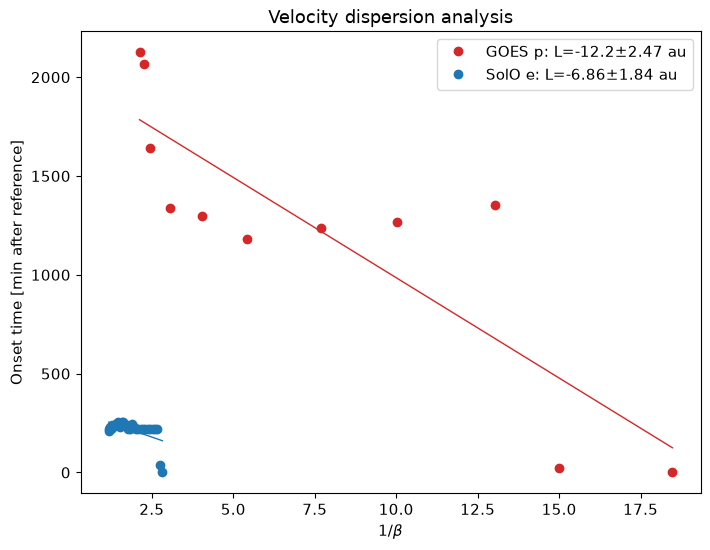

In [57]:
if vda_results:
    fig, ax = plt.subplots(figsize=[8, 6])
    for out, color in zip(vda_results, ['tab:red', 'tab:blue']):
        ax.plot(out['x'], out['y'] / 60, 'o', color=color,
                label=f"{out['observer']} {out['species']}: L={out['L_au']}±{out['L_err_au']} au")
        xx = np.linspace(out['x'].min(), out['x'].max(), 10)
        ax.plot(xx, np.polyval(out['fit'], xx) / 60, '-', color=color, lw=1)
    ax.set_xlabel(r'$1/\beta$')
    ax.set_ylabel('Onset time [min after reference]')
    ax.set_title('Velocity dispersion analysis')
    ax.legend()
    savefig(fig, 'vda')
    plt.show()

## 11. Synthesis: the release-time ledger

Everything on one axis: QPP interval and pulses, type III group, type II/IV onsets, CME
acceleration phase, and the VDA release times (shifted to photon-arrival for comparison).
The question the figure answers: **do particle release times line up with the bursty flare
phase, with shock formation, or with neither?** — the flare-vs-shock weighing is then an
interpretation, stated with its assumptions, not a by-product of plotting.

saved .//2026-01-18/figures/release_time_ledger.pdf|png


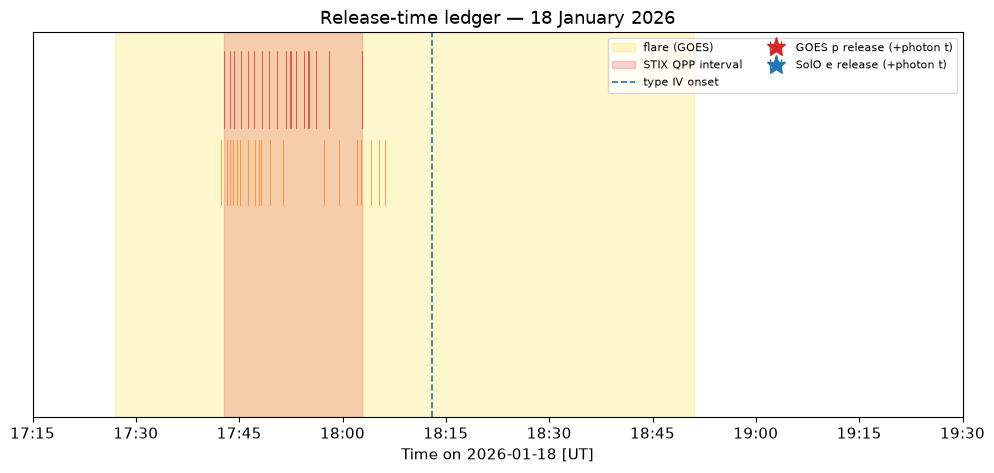

In [59]:
fig, ax = plt.subplots(figsize=[12, 5])

ax.axvspan(t_flare['flare_onset'], t_flare['flare_end'], color='gold', alpha=0.2, label='flare (GOES)')
if len(pulse_df):
    ax.axvspan(pulse_df['t_peak'].min(), pulse_df['t_peak'].max(), color='tab:red', alpha=0.2,
               label='STIX QPP interval')
    for tp in pulse_df['t_peak']:
        ax.axvline(tp, color='tab:red', lw=0.5, ymin=0.75, ymax=0.95)
if have_lwa:
    for t3 in t3_times:
        ax.axvline(t3, color='tab:orange', lw=0.5, ymin=0.55, ymax=0.72)
ax.axvline(t_flare['type_iv_onset'], color='tab:blue', lw=1.2, ls='--', label='type IV onset')

for out, color in zip(vda_results, ['tab:red', 'tab:blue']):
    r_au = results.get('Solar_Orbiter_r_au', 1) if out['observer'] == 'SolO' else 1
    t_photon = out['t_release'] + pd.Timedelta(seconds=499 * r_au)
    ax.errorbar(mdates.date2num(t_photon), 0.25 if out['species'] == 'p' else 0.35,
                xerr=out['t_release_err_s'] / 86400,
                fmt='*', ms=14, color=color, capsize=4,
                label=f"{out['observer']} {out['species']} release (+photon t)")

ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlim(pd.Timestamp('2026-01-18T17:15:00'), pd.Timestamp('2026-01-18T19:30:00'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel(f"Time on {event['date']} [UT]")
ax.set_title('Release-time ledger — 18 January 2026')
ax.legend(loc='upper right', fontsize=8, ncol=2)
savefig(fig, 'release_time_ledger')
plt.show()

In [60]:
summary = pd.Series(results, name='value')
summary.to_csv(f'{res_dir}/summary_measurements.csv')
summary

n_pulses_25_50                                                           19
median_waiting_time_s                                                  56.0
rednoise_alpha                                                          2.2
fourier_periods_s         [140.0, 131.2, 123.5, 67.7, 65.6, 63.6, 61.8, ...
wavelet_period_s                                                       66.1
typeIII_hxr_match_frac                                                 0.42
Solar_Orbiter_r_au                                                    0.745
Solar_Orbiter_lon_deg                                                   8.2
STEREO-A_r_au                                                         0.964
STEREO-A_lon_deg                                                       51.5
PSP_r_au                                                              0.716
PSP_lon_deg                                                          -157.3
open_fraction_ar                                                       0.17
vda_GOES_p_L

**Interpretation checklist before writing up** — each item observation-first:
match between QPP period and any radio/SXR-derivative period (report null results too);
type III-HXR match fraction against a shuffled-times control; VDA release vs QPP interval
with the low-energy bias caveat; shock-formation time vs proton release; connectivity
quality per observer. Ground-based context (Kamen: Antarctic VLF/HF and Rozhen
neutron-monitor/B-field) and the L1/geomagnetic chapter are deliberately out of scope here
and slot in as a separate notebook.

In [61]:
import stixpy
import pycwt as pycwt_mod
print('versions —',
      'sunpy', sunpy.__version__, '| stixpy', stixpy.__version__,
      '| numpy', np.__version__, '| pandas', pd.__version__,
      '| pycwt', getattr(pycwt_mod, '__version__', '?'))

versions — sunpy 6.1.1 | stixpy 0.2.1 | numpy 1.26.4 | pandas 2.3.3 | pycwt 0.4.0b1.dev10+g3343016af.d20251028
